# Statistical Measures and Distributions

Different from what our linear sketch of the "typical data science workflow" might suggest, it is generally not at a single moment that we inspect our data. Instead, we inspect our data frequently, with varying focus and depths.

In the previous sections, we saw that the collection and technical handling (e.g., importing) of data already includes a certain degree of data inspection. Then, during data cleaning, we had to look closely at what is in the data and what might be missing. Now, we want to take the next step, which is often done by doing basic statistics and other quick data explorations. A good data exploration phase is like getting a quick snapshot of the data's characteristics, anomalies, patterns, and relationships. This foundational step often happens immediately after or even during the data acquisition and cleaning phases.

A comprehensive understanding of the data often starts with **basic statistical measures**. These measures provide concise summaries, allowing data scientists to quickly grasp the main tendencies and dispersions in the dataset. Many of you will (hopefully) already know many of the measures listed in this chapter, so the following is mostly meant as a quick refresher. For those of you who feel lost when it comes to basic statistics, it would make sense to invest some more time to gain a solid foundation of basic statistics. Luckily, there are many books, tutorials, and courses on this matter, for instance, the [w3schools website](https://www.w3schools.com/statistics/index.php).

### Measures of Central Tendency
These are quintessential in understanding where the 'center' of our data lies.

**Mean (Arithmetic Mean)**: The arithmetic mean is calculated as the sum of all values divided by the number of values. It's a common measure to determine the central value in a dataset. Mathematically, if $X$ is a dataset with $n$ values, the mean $\mu$ is calculated as:
$$
\mu=\frac{1}{n}\sum_{i=1}^n x_i
$$

**Median**: The median is the middle value of an ordered dataset, separating the higher and lower half. If the dataset has an odd number of observations, the median is the middle number. If there's an even number, it's the average of the two middle numbers.

**Mode**: Represents the value that appears most frequently in a dataset. Datasets can have one mode, more than one mode, or no mode at all.

### Quantiles
Quantiles divide ordered data into parts of equal size. The median is the 0.5-quantile, quartiles divide the data into four parts, deciles into ten, and percentiles into one hundred.

- **Median**: Also known as the 0.5-Quantile, representing the 50th percentile.
- **Quartile**: Segments the data into 4 equal parts.
- **Deciles**: Segments the data into 10 equal parts, marking every 10th percentile.
- **Percentiles**: Denotes specific positions in a data set divided into 100 equal parts.

### Measures of Spread
While central tendency gives an overview of the data's central point, measures of spread describe how much the data tends to deviate from that point.

**Standard Deviation (STD)**: It quantifies the dataset's variation. A low standard deviation means that values are close to the mean, while a high standard deviation indicates that values are spread out over a wider range.
$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
$$

**Interquartile Range**: Represents the range between the first (25th percentile) and third quartiles (75th percentile).  
**Range**: It’s the most straightforward measure of spread and is calculated as the difference between the maximum and minimum values in the dataset.  
**Variance**: The average of the squared differences from the mean, often denoted as σ2σ2.  

---

### Exercise: Understanding Statistics in a Practical Scenario

Consider the 3rd semester of Media Informatics: The average age (mean) of the students = 22.7 years, Standard Deviation (STD) = 2.1 years

Try to answer the following questions:

1. Given the mean and standard deviation, is it probable for there to be students in the 3rd semester of Media Informatics who are older than 40 years?
2. Based on the mean and standard deviation alone, can we sensibly estimate the minimum and maximum age? Why or why not
3. Can we conclude from the mean alone whether most students are above or below 22.7 years of age?

Below is a quick summary of the measures discussed:

| Measures                   | Description                                                  | Nominal | Ordinal | Quantitative | Accounts for All Values | Sensitive to Outliers |
| -------------------------- | ------------------------------------------------------------ | :-----: | :-----: | :----------: | :---------------------: | :-------------------: |
| **Mode**                   | Most frequent value                                          |    x    |    x    |      x       |                         |                       |
| **Median**                 | Central value with equal numbers of data points above and below |         |    x    |      x       |                         |                       |
| **Mean (Arithmetic Mean)** | Average value                                                |         |         |      x       |            x            |           x           |
| **Geometric Mean**         | Average of growth rates; multiplicatively linked             |         |         |      x       |            x            |           x           |
| **Harmonic Mean**          | Average of fractions with a constant denominator or a special case of weighted arithmetic mean |         |         |      x       |            x            |           x           |
| **Quantile / Quartile**    | Value below which a specified percentage of observations fall |         |         |      x       |                         |                       |
| **Minimum / Maximum**      | Smallest and largest values respectively                     |         |    x    |      x       |                         |           x           |



## Statistical Measures and Distributions

Let us look at some distributions and their statistical measures. In the following Python code cells we will import the required libraries and define a simple plotting function for the task.

In [2]:
import os

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb

# Set the ggplot style
plt.style.use("ggplot")

For later use we define a `plot_dist` function which can display a distribution as well as the mean and median values.

In [3]:
def plot_dist(
    data,
    bins=30,
    add=["mean"],
    lower_bound=None, upper_bound=None, 
    figsize=(8, 6)
):
    """Enhanced plotting function to display distributions with statistics annotations,
    with options to restrict the histogram's bounds.

    Parameters:
        data (array-like): The full dataset used for statistical computations.
        bins (int): Number of histogram bins.
        add (list): List of statistics to annotate. Options: "mean", "median".
        lower_bound (float, optional): Lower bound for the histogram plot.
        upper_bound (float, optional): Upper bound for the histogram plot.
        figsize (tuple): The figure size.
    """
    def add_stat(value, height, name, color="crimson"):
        """Draw a vertical line at the statistic's value"""
        ax.axvline(value, color=color, linestyle='--', linewidth=2)

        # Check if the text is going out of bounds on the right
        if value > ax.get_xlim()[1] * 0.95:
            value = ax.get_xlim()[1] * 0.95
        ax.text(value, height, f" {name}: {value:.2f}",
                color=color,
                verticalalignment='center')

    # For histogram, only use data within the provided bounds.
    data_hist = data
    if lower_bound is not None:
        data_hist = data_hist[data_hist >= lower_bound]
    if upper_bound is not None:
        data_hist = data_hist[data_hist <= upper_bound]

    # Create the histogram using the bounded data.
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    counts, bins, patches = ax.hist(data_hist, bins=bins, rwidth=0.8,
                                    color="steelblue", alpha=0.75)

    max_height = np.max(counts)

    # Compute statistics on the full data.
    if "mean" in add:
        mean_value = np.mean(data)
        add_stat(mean_value, 0.9 * max_height, "mean")
    if "median" in add:
        median_value = np.median(data)
        add_stat(median_value, 0.8 * max_height, "median", "purple")

    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution with Statistical Annotations')
    #plt.show()

### Symmetric Distribution

Symmetric distributions are those where values are distributed in a way that the shape on one side of the centerline mirrors the shape on the other. In other words, the left half of the distribution is a mirror image of the right half. One of the key properties of a symmetric distribution is that the mean and median will be the same, or very close.

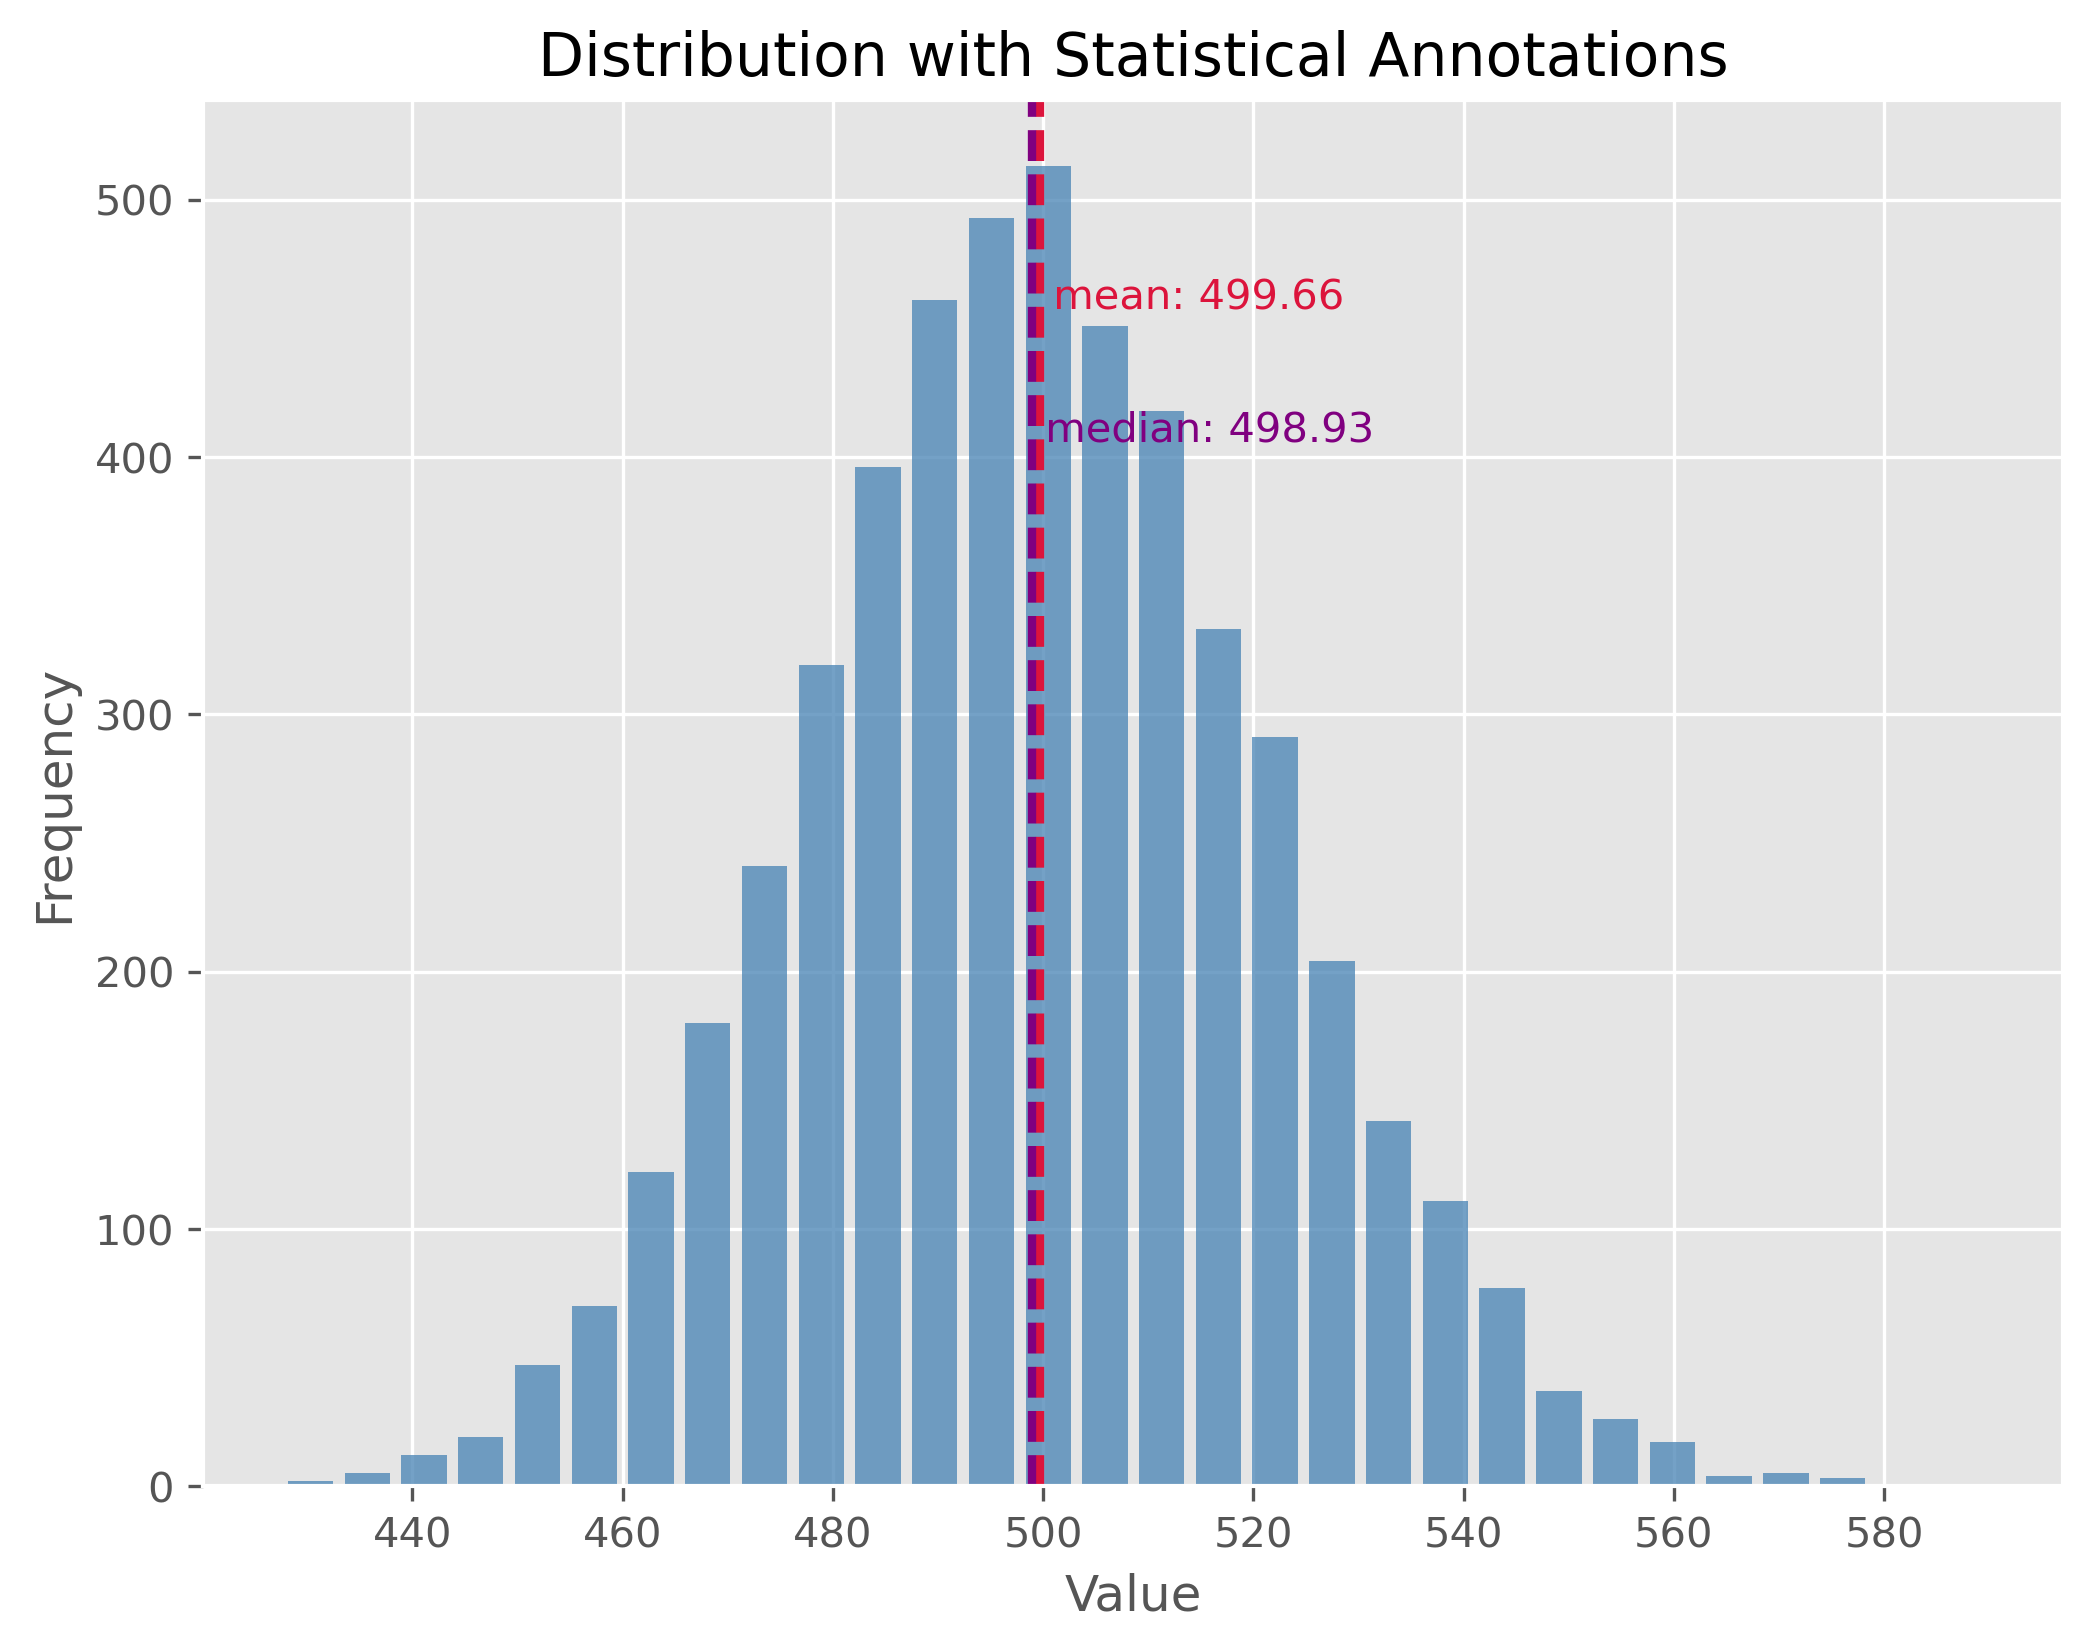

In [4]:
np.random.seed(0)
data = np.random.gamma(500, 1, 5000)
plot_dist(data, 30, ["mean", "median"])

### Non-symmetric Distributions

In reality, most of the data we encounter tends to be non-symmetric. These distributions don't exhibit mirror-like symmetry around their center. It is important to note here, especially for non-symmetric distributions, the mean might not necessarily represent the "center" of the data.

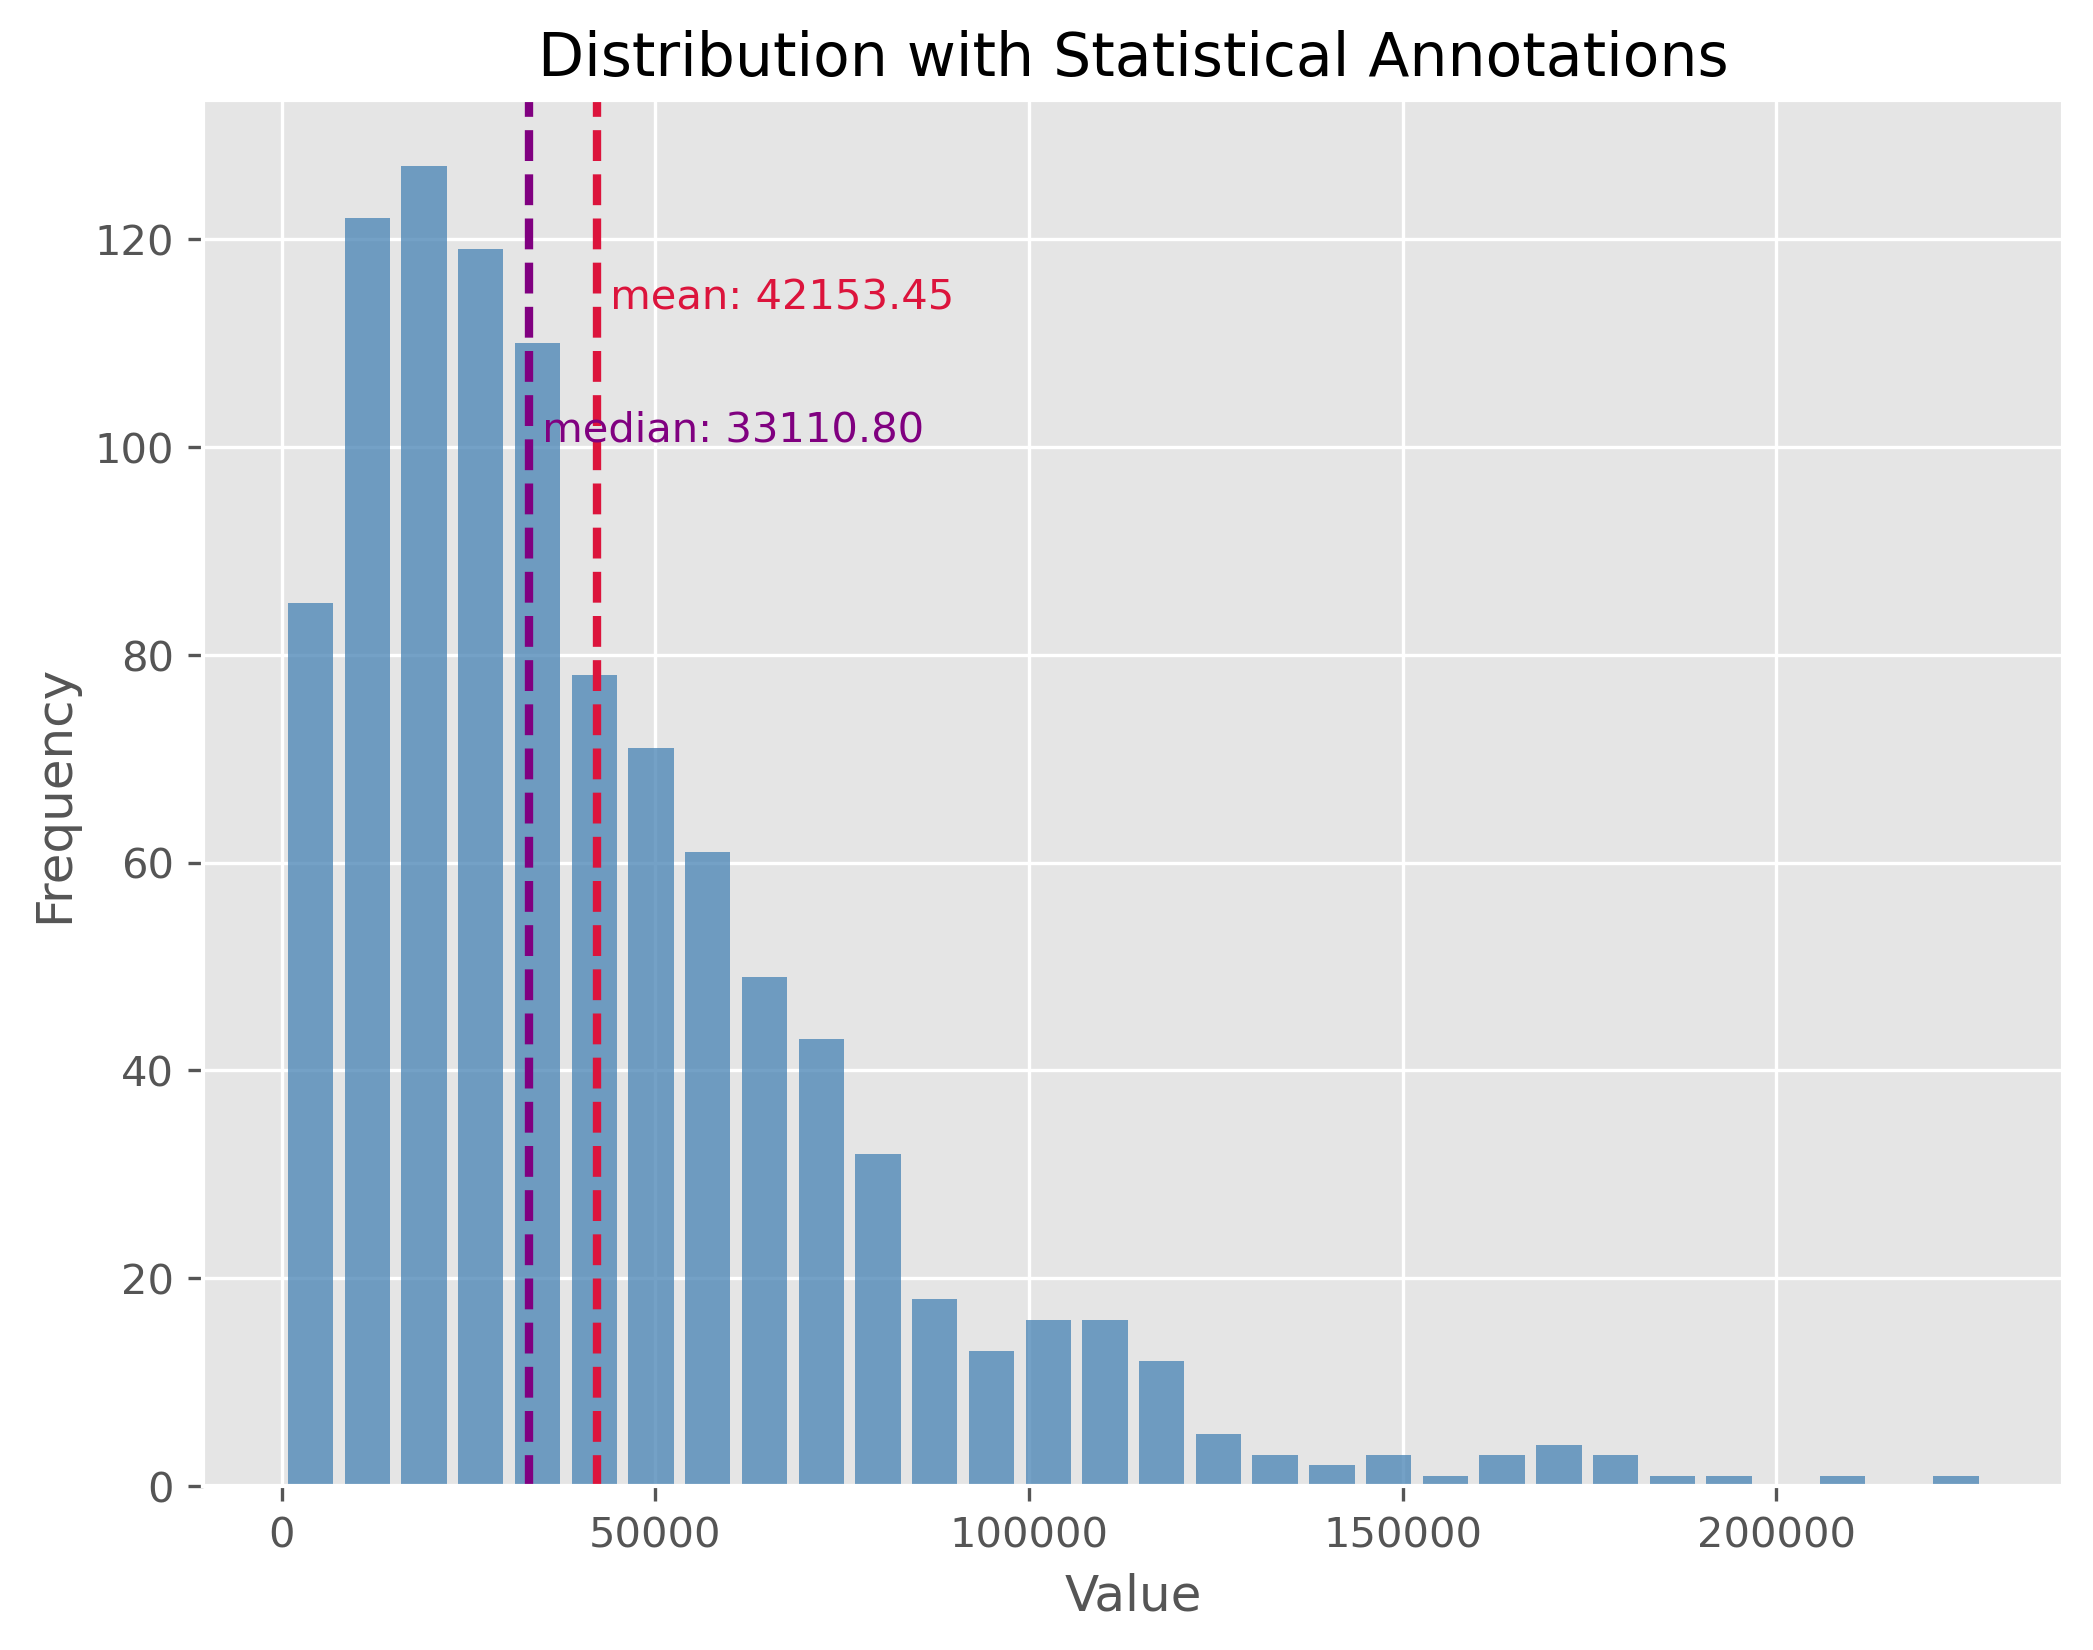

In [5]:
data = np.random.gamma(1.6, 26000, 1000)
plot_dist(data, 30, ["mean", "median"])

### Distributions with Outliers

Outliers are values that stand apart from the bulk of the data. Their presence can distort our perceptions about the data and can notably skew our mean. It's essential to identify and manage outliers for better statistical interpretations.

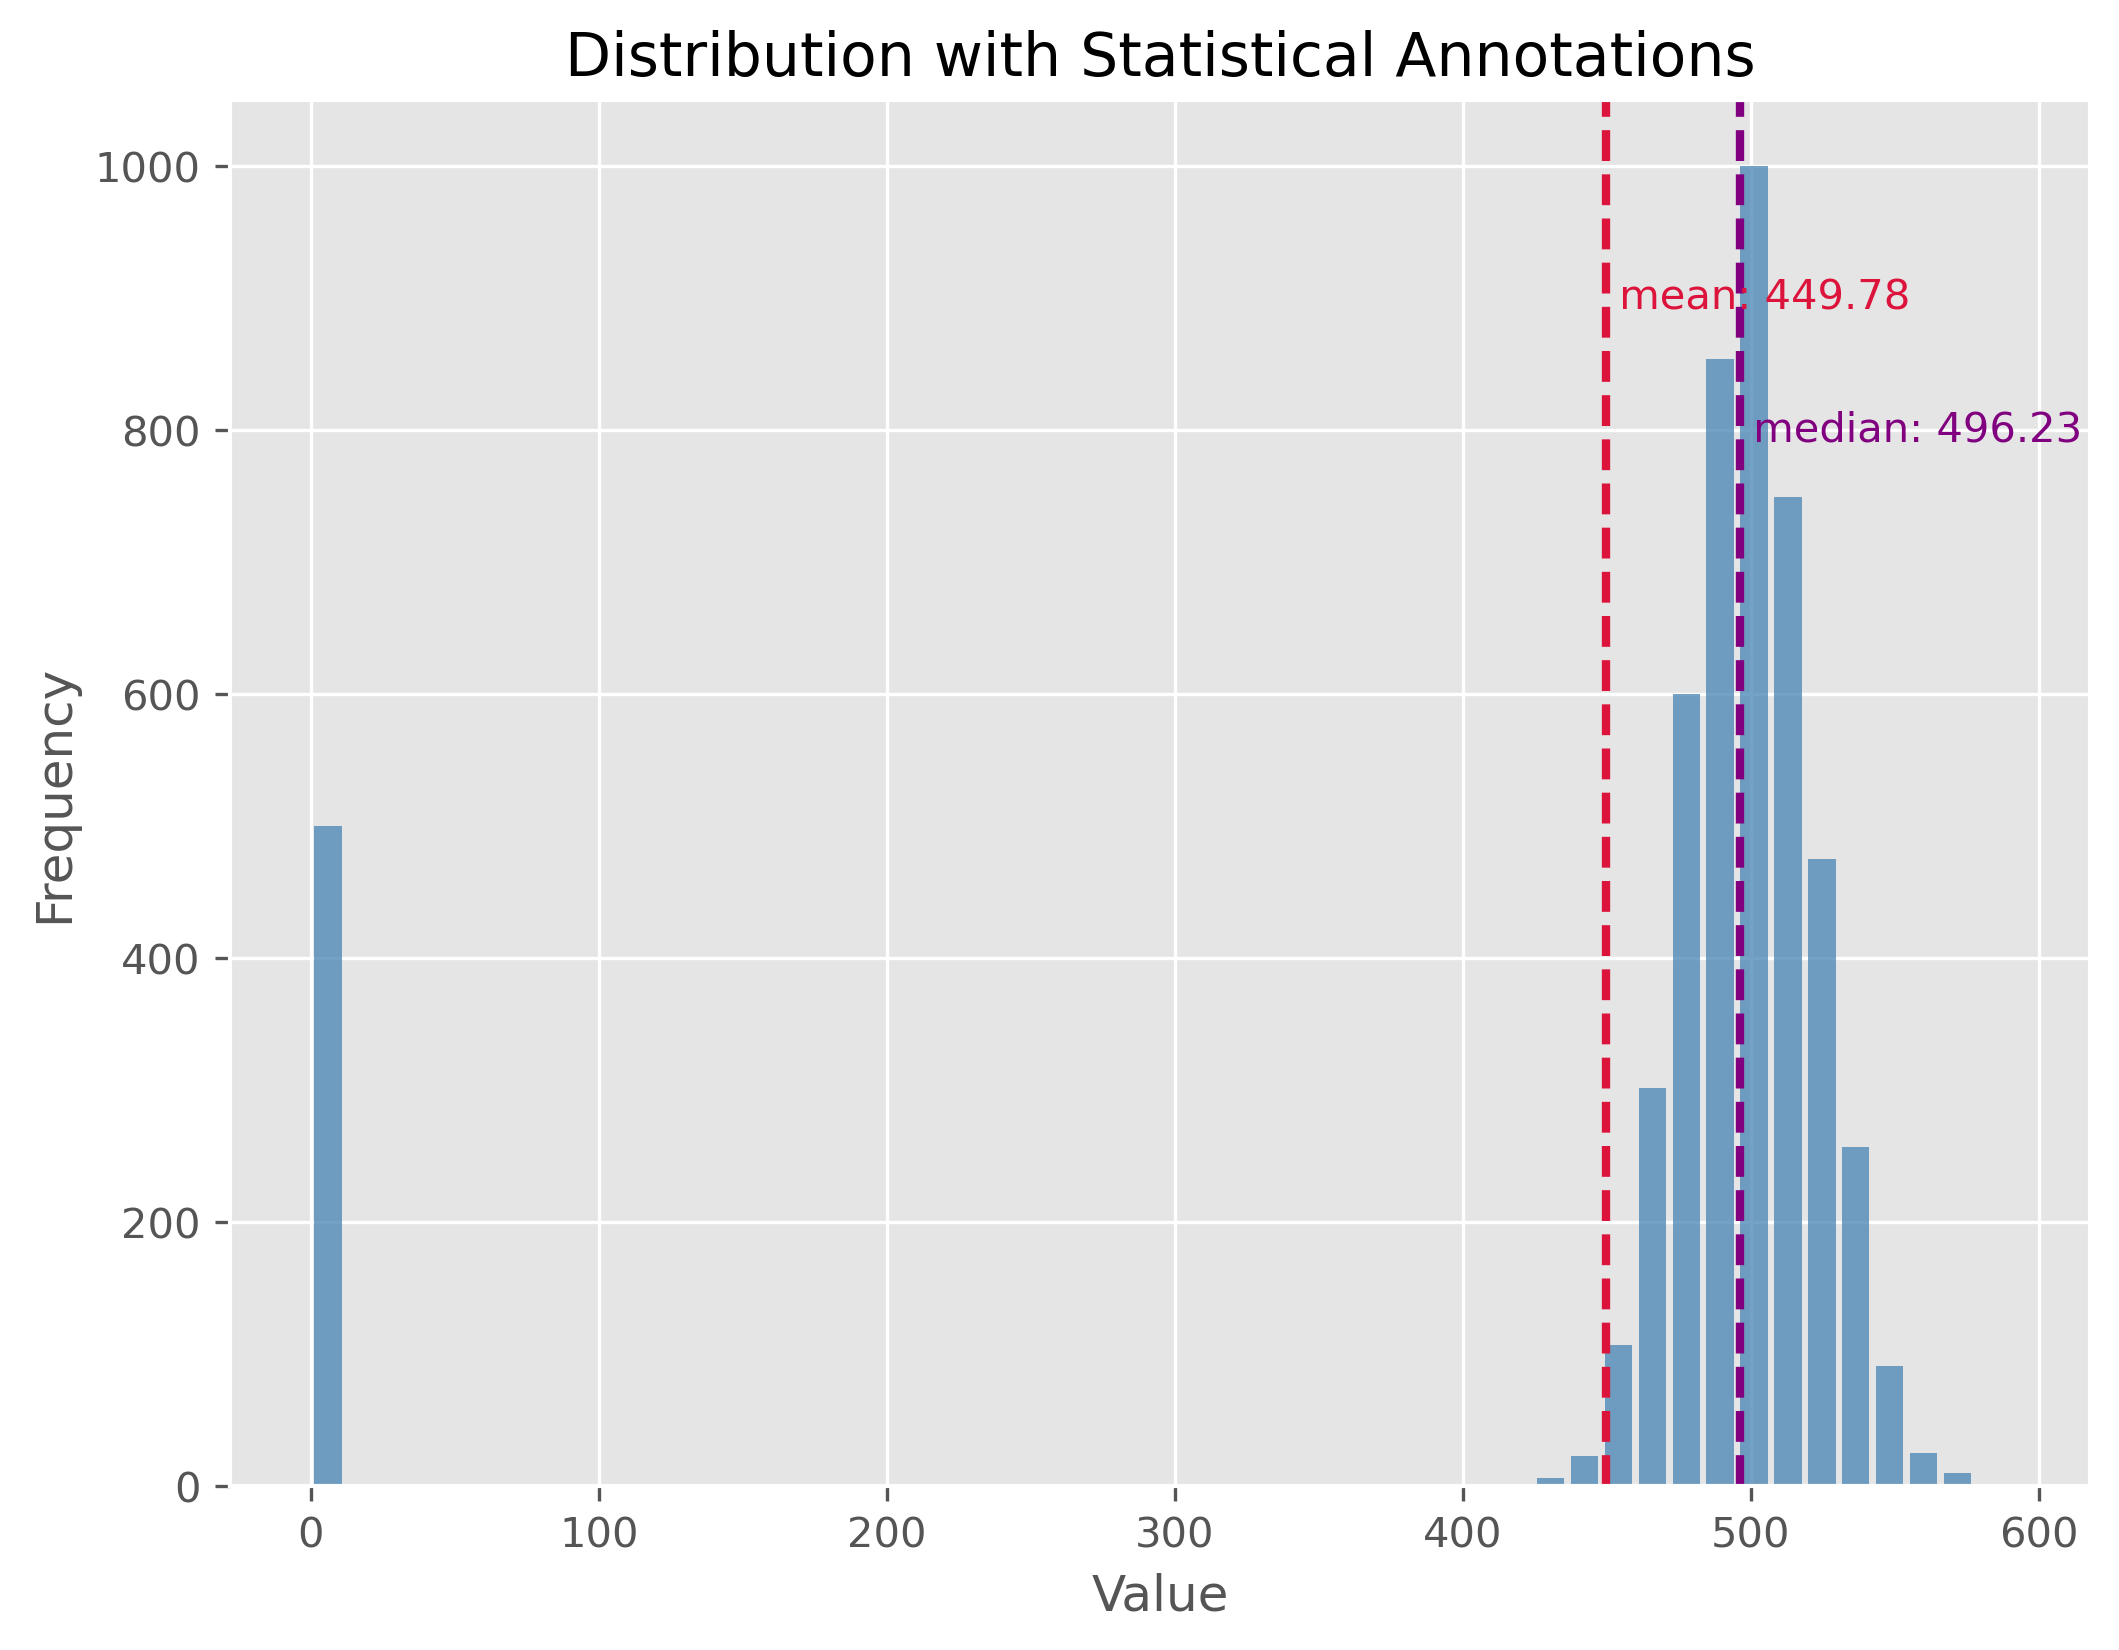

In [6]:
np.random.seed(0)
data = np.random.gamma(500, 1, 5000)
data[:500] = 0
plot_dist(data, 50, ["mean", "median"])

If you look at the distribution plot with the median and the mean: Which of the two measures is better in this case (and why)?

### Mixed Distributions

At times, our dataset may not belong to a single type of distribution. Instead, it may be the result of a mix of two or more underlying distributions. This phenomenon is observed in mixed distributions. Recognizing and understanding the different underlying distributions can be crucial for analysis.

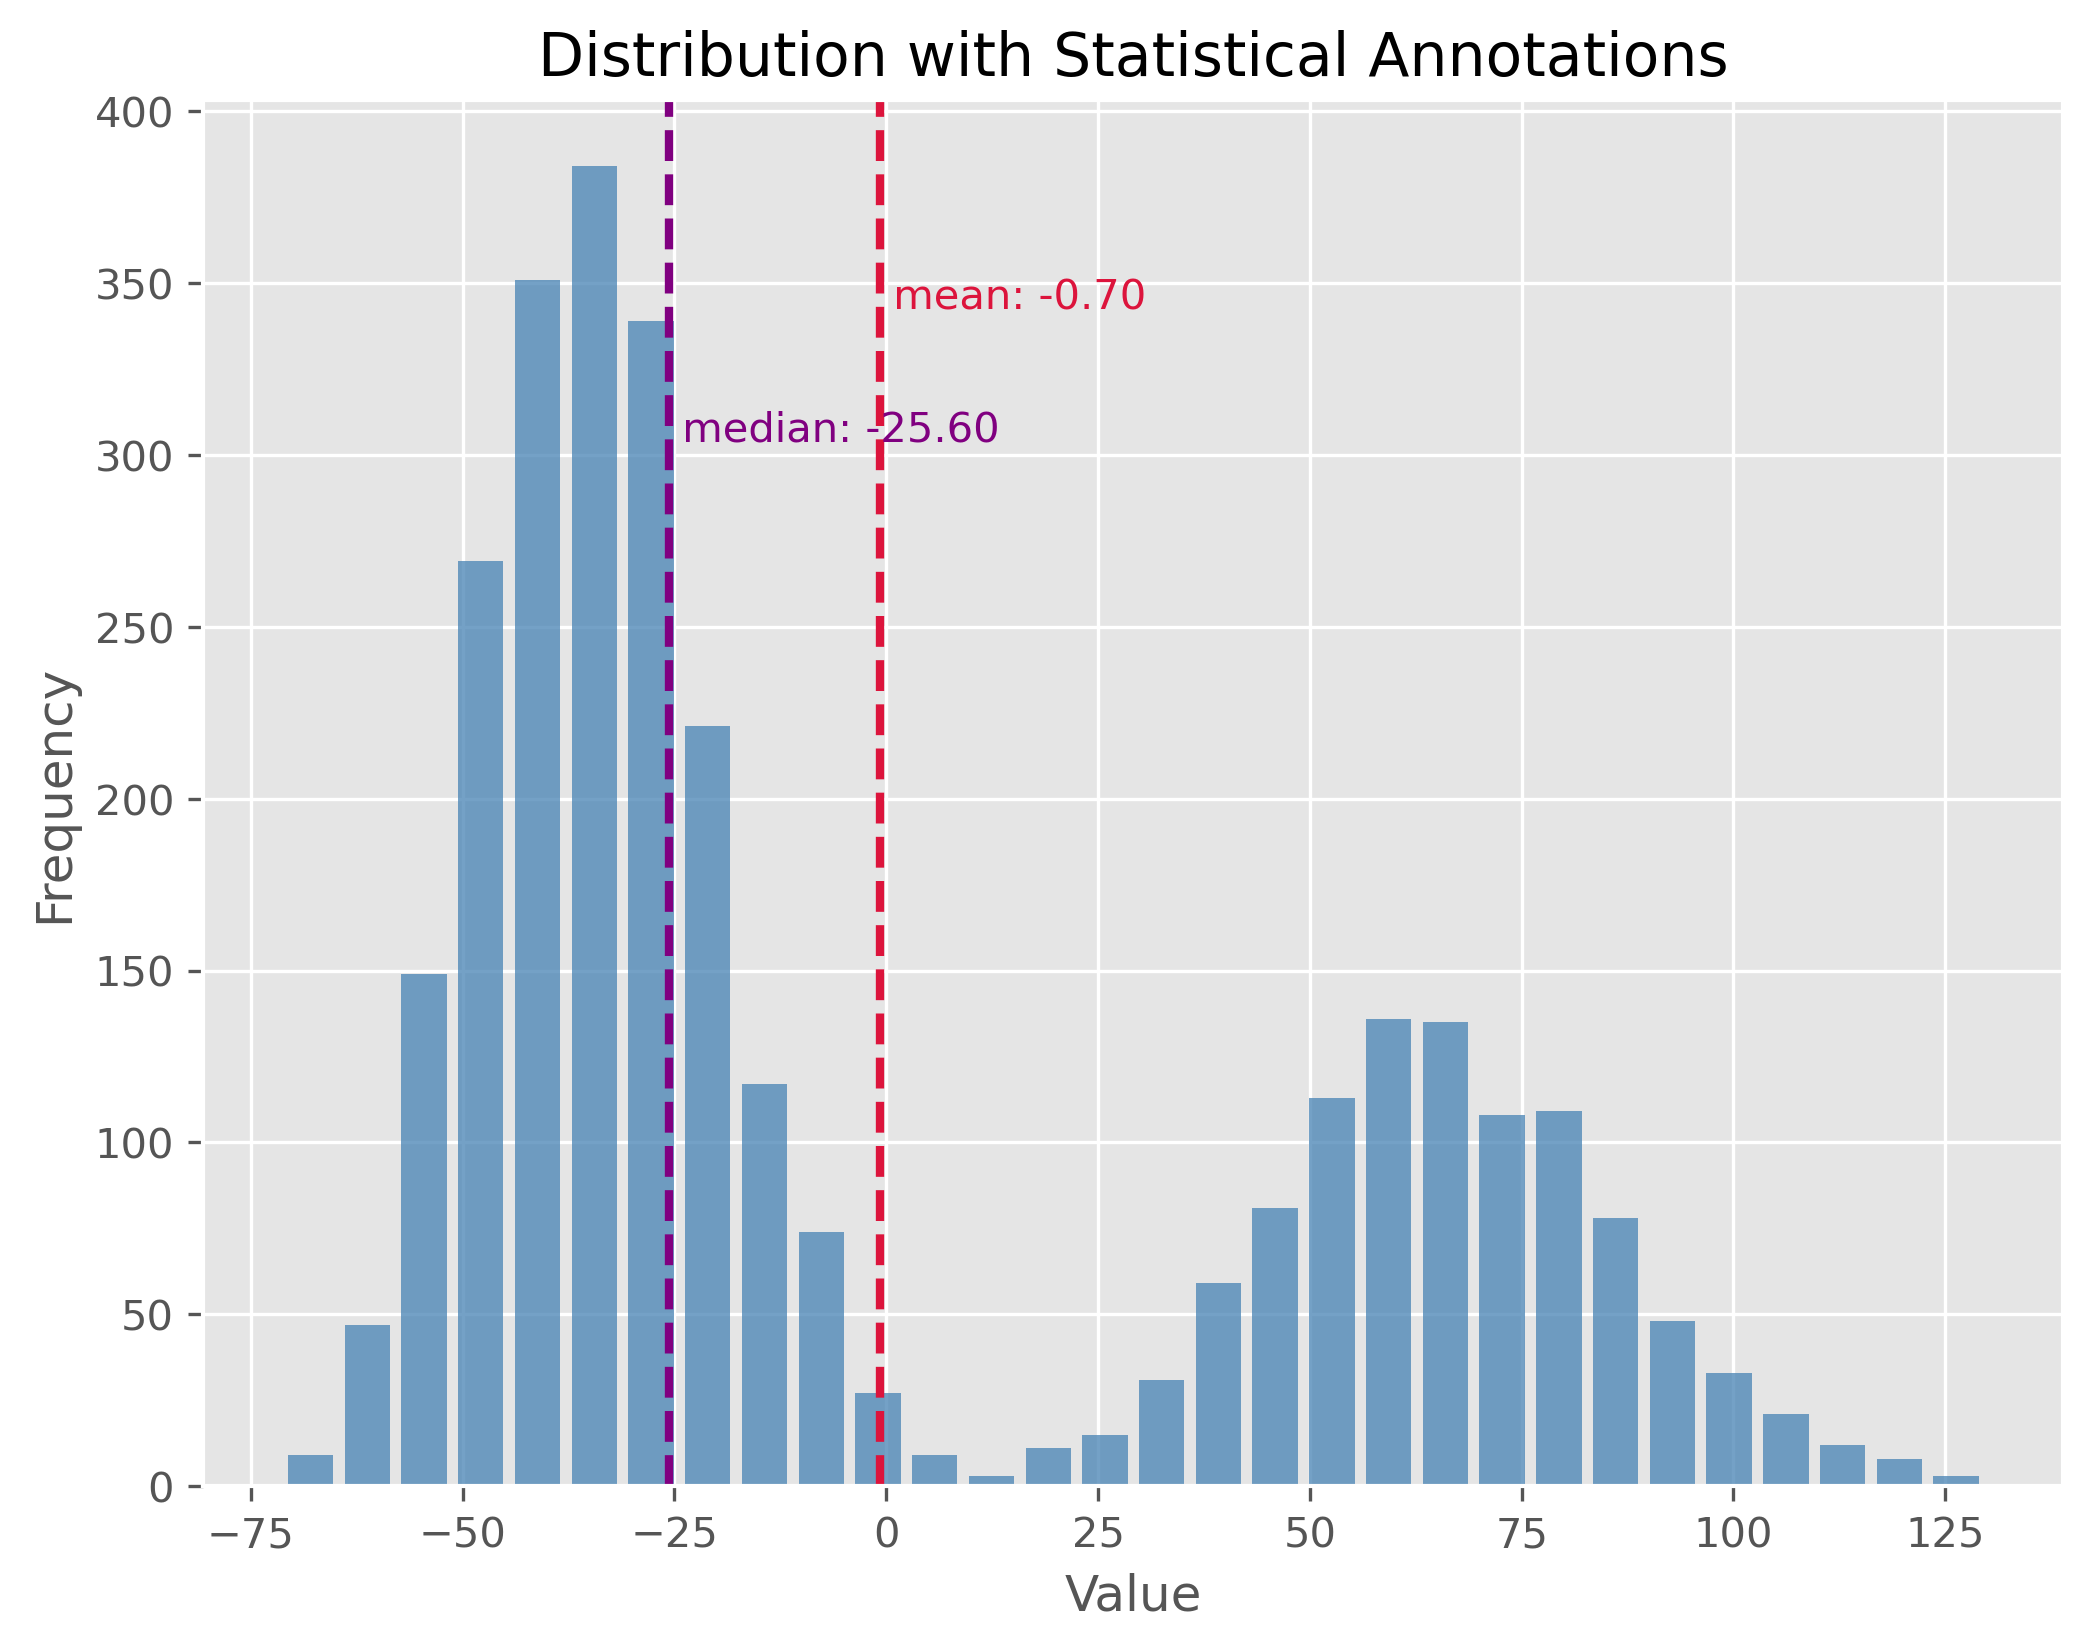

In [7]:
np.random.seed(0)
data1 = np.random.gamma(50, 2, 2000)
data2 = np.random.gamma(100, 2, 1000)
data = np.concatenate((data1, data2)) - 134

plot_dist(data, 30, ["mean", "median"])

Here again: If you look at the distribution plot with the median and the mean, which of the two measures is better in this case (and why)?

### Statistical Measures

After observing the distributions, let's also calculate key statistical measures and see what insights they provide regarding the distribution's characteristics.

In [8]:
print(np.std(data))
print(np.min(data), np.max(data))
print(np.quantile(data, 0.5))
print(np.quantile(data, 0.9))
print(np.percentile(data, [25 ,75]))

50.09713754299179
-71.30263005114779 129.6311878602093
-25.604183317689994
76.81243703053997
[-39.37861049  52.79716049]


## Statistical dispersion

Statistical dispersion refers to the spread or variability of a dataset. It helps to understand the extent to which individual data points deviate from the mean. While two distributions might have similar centers (mean or median), their characteristics could differ considerably in terms of spread. For instance, one might be tightly clustered around the mean, whereas the other might be more spread out.

Dispersion can be illustrated with two distributions that have the same center (mean) but different standard deviations. In the following examples, both distributions are centered at 100, but they have standard deviations of 15 and 1.5, respectively. The standard deviation (often referred to as "STD") is a measure that tells us how spread out the numbers in a distribution are.

A higher standard deviation indicates that the data points tend to be farther from the mean, while a smaller standard deviation suggests that they are clustered closely around the mean.

STD: 14.81


(52.0, 148.0)

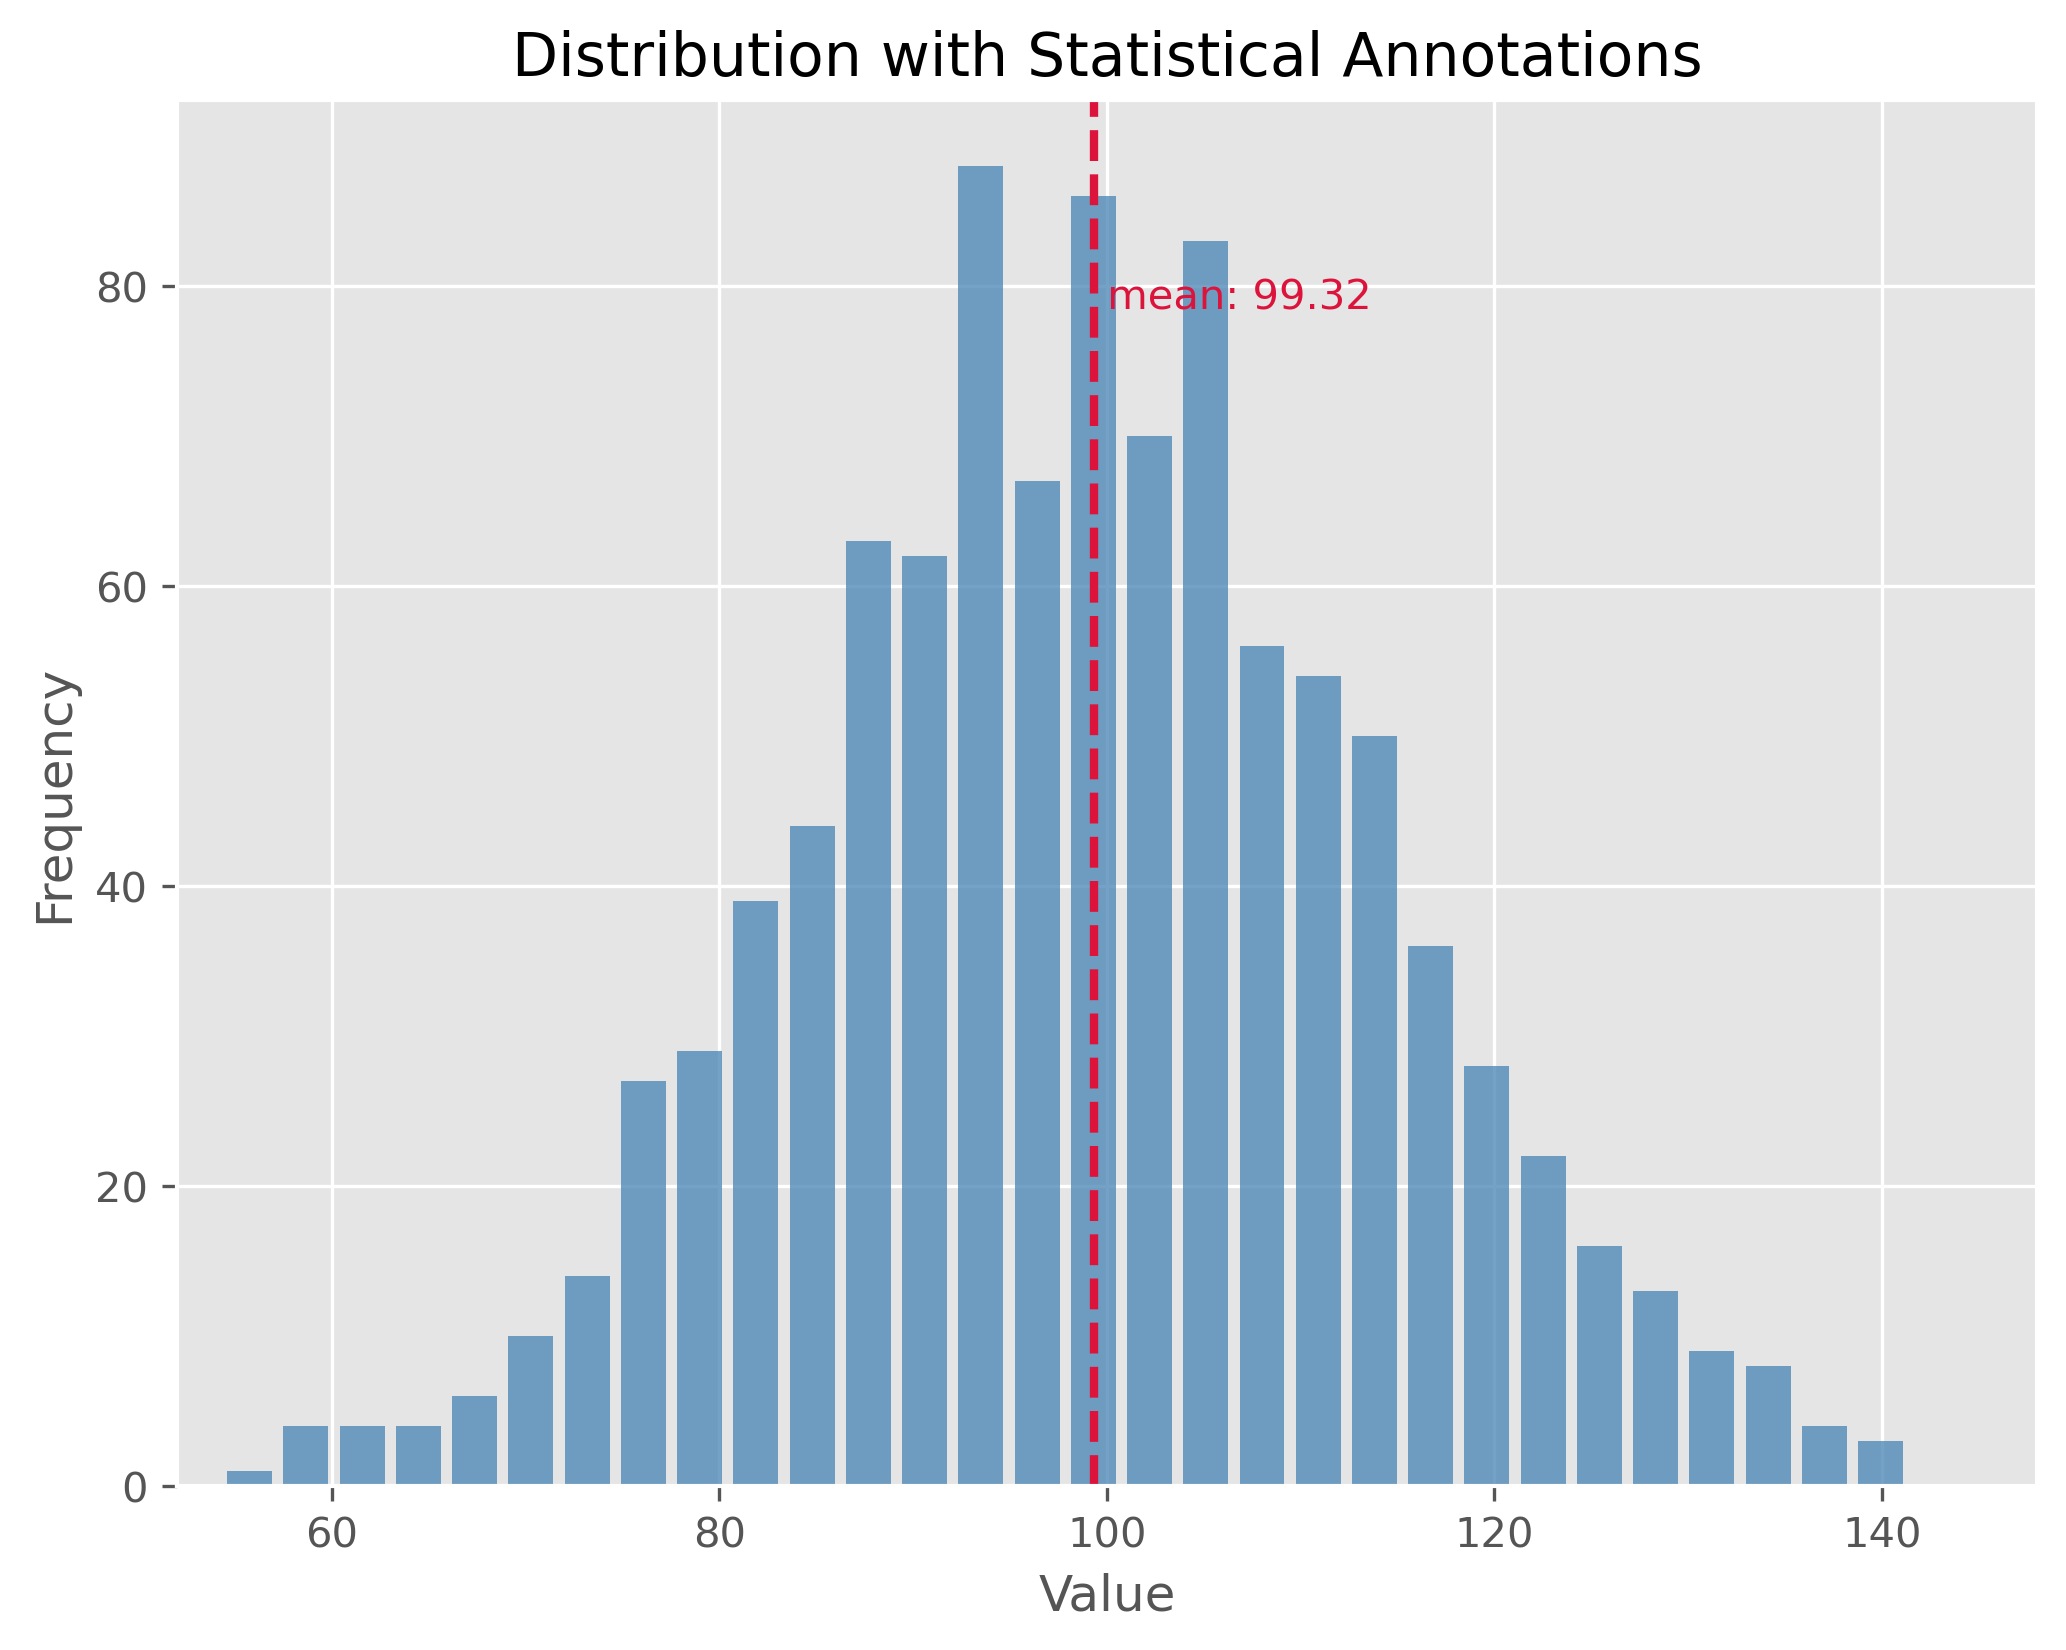

In [9]:
np.random.seed(0)
data = np.random.normal(100, 15, 1000)

plot_dist(data, 30, ["mean"])
print(f"STD: {np.std(data):.2f}")
plt.xlim(52, 148)

The plot above showcases a normal distribution with a mean of 100 and a standard deviation of 15. The data points are spread relatively far from the mean, resulting in a wider bell shape.

STD: 1.47


(52.0, 148.0)

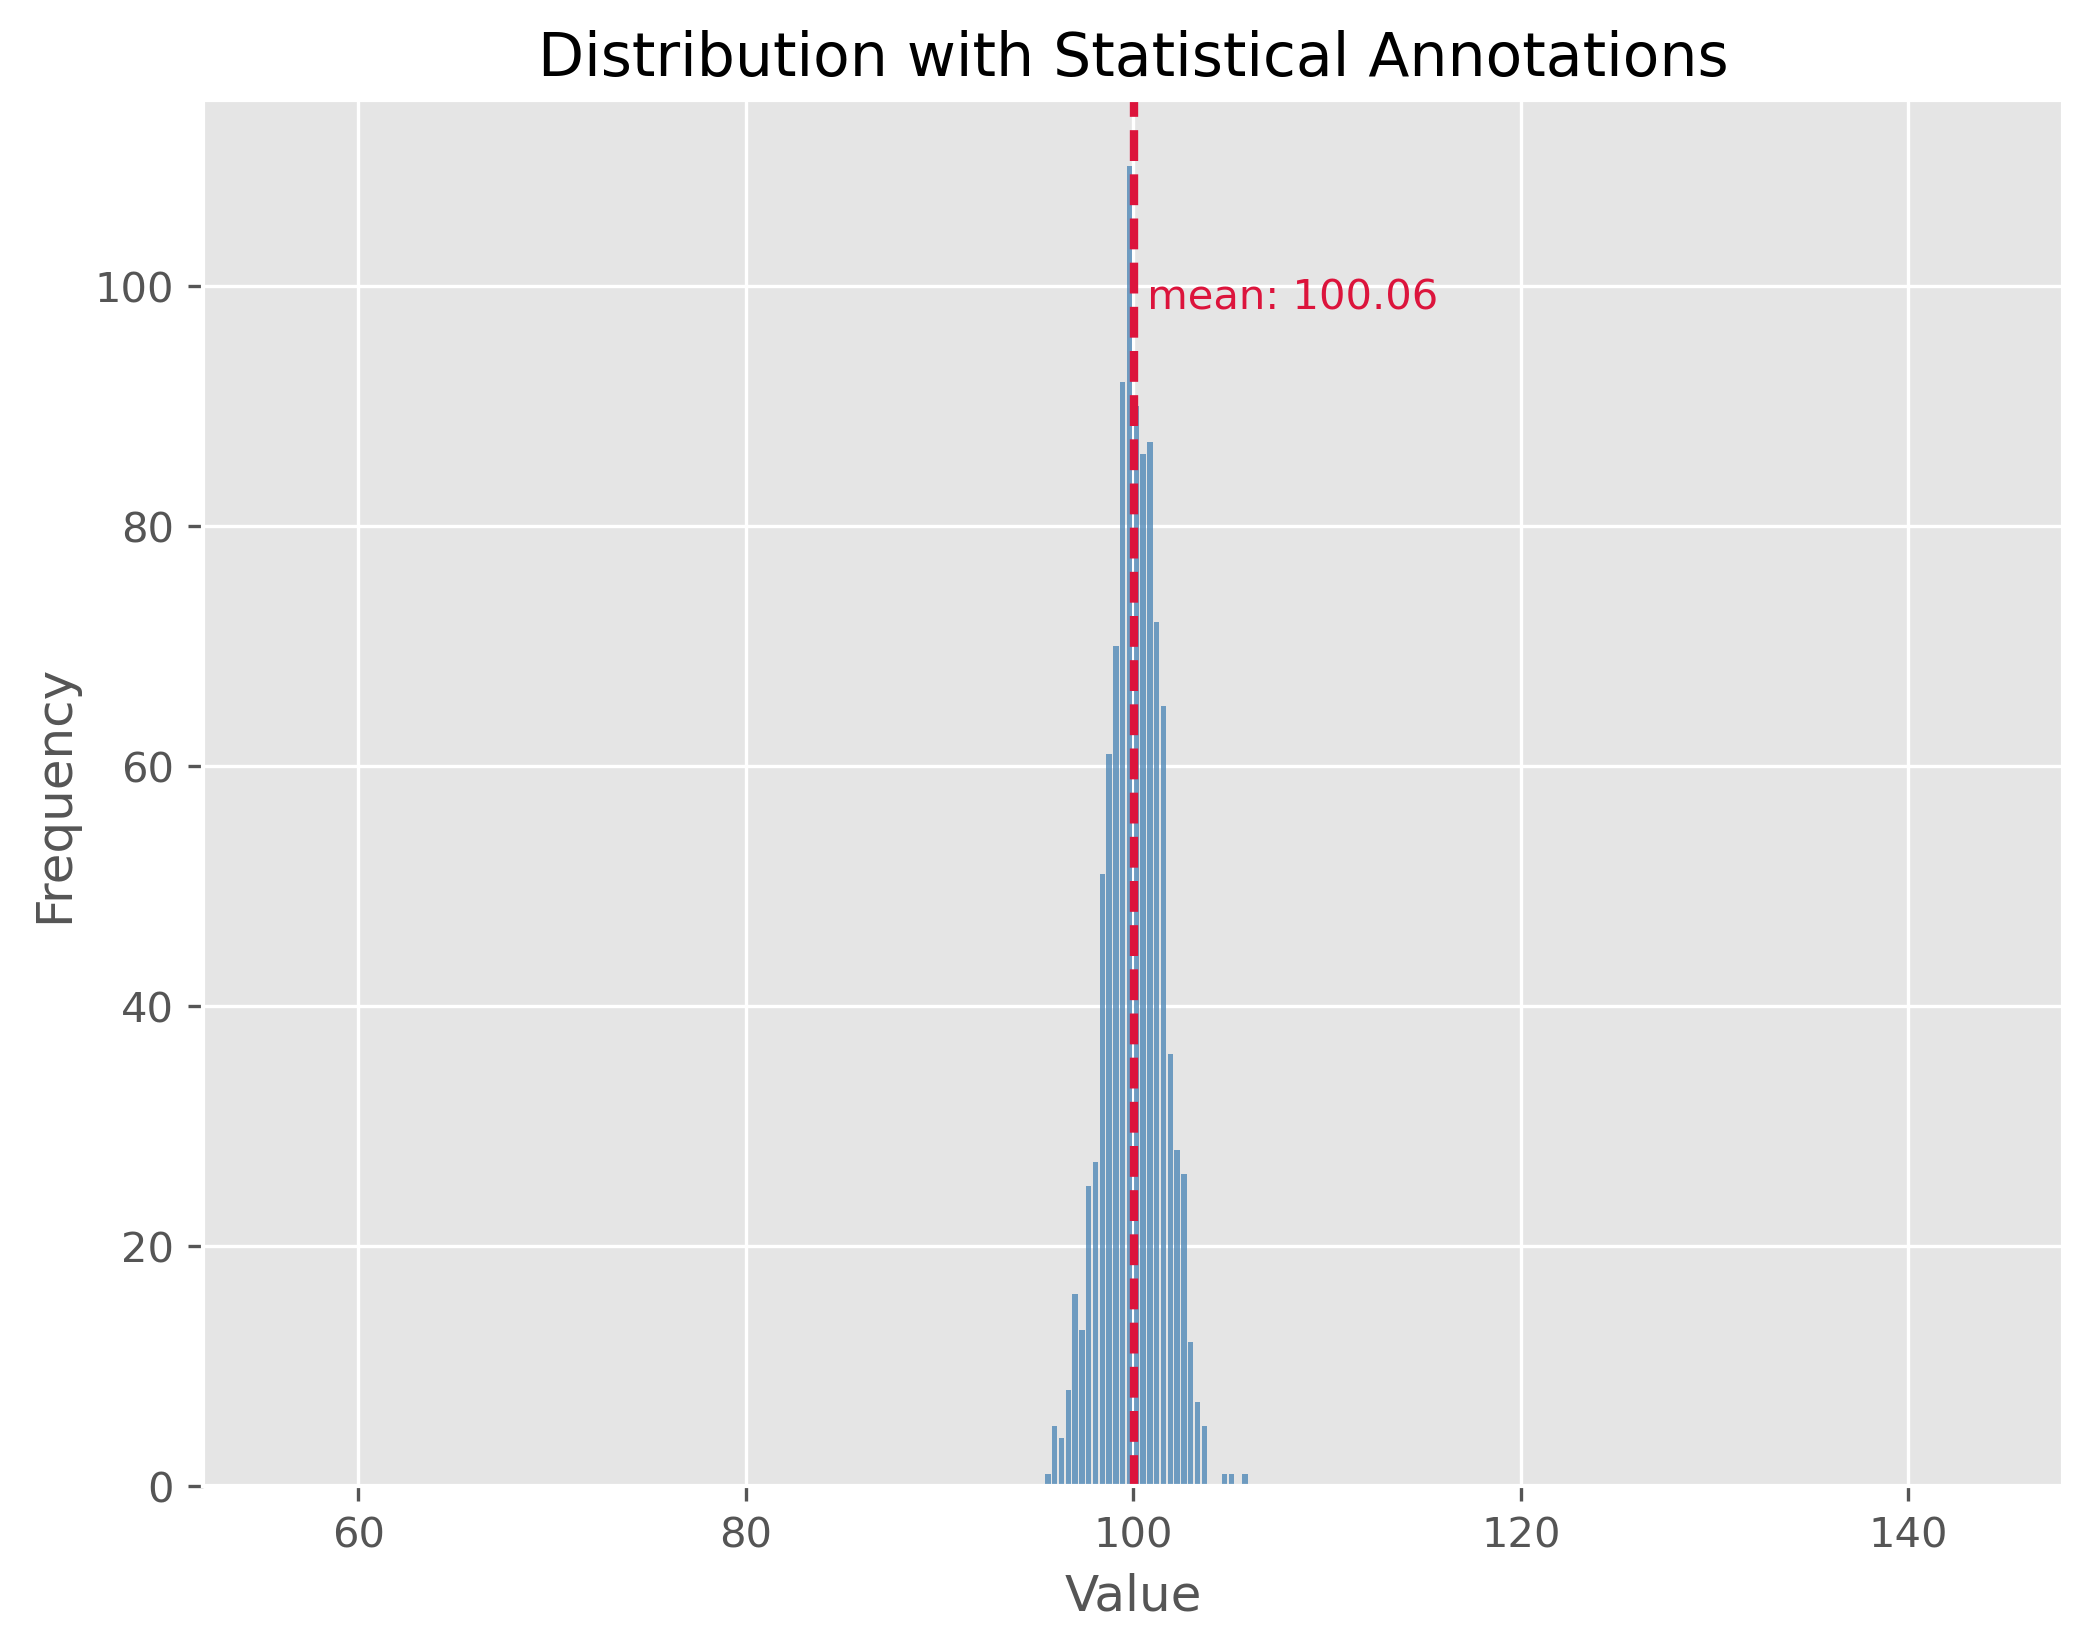

In [10]:
np.random.seed(1)
data = np.random.normal(100, 1.5, 1000)

plot_dist(data, 30, ["mean"])
print(f"STD: {np.std(data):.2f}")
plt.xlim(52, 148)

In contrast, the second plot demonstrates a distribution with the same mean of 100 but with a much smaller standard deviation of 1.5. This causes the data to be tightly clustered around the mean, making the bell shape much narrower.

By comparing the two plots, we observe the significance of the standard deviation in understanding the distribution's spread. While both distributions share the same center, their spreads are vastly different, and recognizing this difference is crucial in many statistical analyses and applications.

## What can statistical measures do (and what not)?
Statistical measures such as *mean* or *median*, or dispersion measures such as *standard deviation* or *range* often allow us to get a **very fast** first impression of a dataset. But we have to be careful not to put too much weight on those fairly basic statistical values.

In [11]:
filename = r"https://raw.githubusercontent.com/florian-huber/data_science_course/a595bd6b19565cedff0c3917012be6e05223f7fb/datasets/datasaurus.csv"

# read data
data = pd.read_csv(filename)

# prepare data
new_names = "ABCDEFGHIJKLMNOP"
convert_names = {x: new_names[i] for i, x in enumerate(data["dataset"].unique())}

data["dataset"] = data["dataset"].apply(lambda x: convert_names[x])

datasets = []
for value in data["dataset"].unique():
    mask = data["dataset"] == value
    datasets.append(data[mask].drop(columns=["dataset"])) 

### First Data Exploration (using basic statistics)
In the code cell above we imported a dataset that consists of 14 different subsets ("A" to "M"). Each data point belongs to only one of those subsets and otherwise consists of only two numerical features: **x** and **y** which can be thought of as a 2D position. 

In [12]:
data.head(3)

,dataset,x,y
0,A,55.3846,97.1795
1,A,51.5385,96.0256
2,A,46.1538,94.4872


We can use Pandas and its `groupby` method to quickly get several important statistical measures on all 14 subsets.

In [13]:
cols = [("x", "count"), ("x", "mean"), ("x", "std"),
       ("y", "count"), ("y", "mean"), ("y", "std")]
data.groupby('dataset').describe()[cols]

x                            y                      
         count       mean        std  count       mean        std
dataset                                                          
A        142.0  54.263273  16.765142  142.0  47.832253  26.935403
B        142.0  54.266100  16.769825  142.0  47.834721  26.939743
C        142.0  54.261442  16.765898  142.0  47.830252  26.939876
D        142.0  54.269927  16.769959  142.0  47.836988  26.937684
E        142.0  54.260150  16.769958  142.0  47.839717  26.930002
F        142.0  54.267341  16.768959  142.0  47.839545  26.930275
G        142.0  54.268805  16.766704  142.0  47.835450  26.939998
H        142.0  54.260303  16.767735  142.0  47.839829  26.930192
I        142.0  54.267320  16.760013  142.0  47.837717  26.930036
J        142.0  54.268730  16.769239  142.0  47.830823  26.935727
K        142.0  54.265882  16.768853  142.0  47.831496  26.938608
L        142.0  54.267849  16.766759  142.0  47.835896  26.936105
M        142.0  54.266916  16.770000  142.0  47.831602  26.937902

### Mini-Exercise: What do you think?
If you compare the mean and standard deviation (std) values for all 13 datasets (A to P), what do you expect them to look like? There is 142 datapoints in each subset. Will the datapoints of each subset be distributed similarly or not?

### Solution

There is only one good way to find out and that is to inspect the data!
Try, for instance, to run the following:

```python
sb.relplot(x="x", y="y", col="dataset", kind="scatter", data=data, col_wrap=4)
```

I won't spoil it here right away, but what this dataset should illustrate once and for all is that basic statistical measures are a good starting point. But they often don't tell us enough about our data! By the way, this dataset is called the **datasaurus** {cite}`matejka_same_2017`.

## Comparing Distributions Visually

When we analyze a given dataset, one of the most fundamental tasks is understanding the underlying distribution. Especially when dealing with multiple datasets, understanding and comparing their distributions can reveal patterns, outliers, and other crucial insights. As we just saw in the above exercise, visualization tools play an invaluable role in this exploration because they can tell us much more than a few statistical measures, such as mean, median, or standard deviation alone. Here's a deeper look at some popular techniques for visual data representation of distributions:

1. **Box Plot**:

   A box plot (or whisker plot) displays a summary of a set of data values. It provides a visual summary of the minimum, first quartile, median, third quartile, and maximum of a dataset.

   - **Pros**:
     - Efficiently represents the data's spread and central tendency.
     - Useful for identifying outliers and comparing distributions across groups.

   - **Cons**:
     - Can be challenging to interpret for those unfamiliar with the plot's elements.
     - It doesn't represent the nuances in distributions; for instance, two very different distributions (like C and D) could have similar box plots.

2. **Strip Plot**:

   A scatter plot where one axis is categorical. It's useful for displaying all items in the dataset.

   - **Pros**:
     - It offers a sense of the density and distribution of data points.
     - Clearly shows individual data points.

   - **Cons**:
     - Can become cluttered and less interpretable with large datasets as points overlap.
     - Doesn't provide summary statistics about the data.

3. **Swarm Plot**:

   Similar to a strip plot where data points are adjusted (or "swarmed") to avoid overlap, giving a clearer representation of the distribution of values.

   - **Pros**:
     - It offers a clearer view of the distribution than strip plots for moderate datasets.
     - Good for visualizing the density of the data.

   - **Cons**:
     - Not suitable for very large datasets as it can become cluttered and slow to render.
     - Like the strip plot, it lacks summary statistics.

4. **Violin Plot**:

   Combines the benefits of both box plots and kernel density plots. It shows the full distribution of the data along with its summary statistics.

   - **Pros**:
     - It offers a detailed view of the data's distribution, including its density.
     - Combines the best of box plots (summary statistics) and density plots (distribution shape).

   - **Cons**:
     - Requires a degree of smoothing, which can be perceived as manipulating or altering the true nature of the data.
     - Can be harder for newcomers to interpret compared to simpler plots.

Using these visualization tools thoughtfully allows us to derive meaningful insights from our data, helping guide our analyses and decision-making.

In [14]:
# create toy data
np.random.seed(0)

data1 = np.random.normal(4, 0.7, 150)
data2 = np.random.normal(1, 0.7, 150)
dataC = np.concatenate((data1, data2))

datasets_test = pd.DataFrame({"A": np.random.gamma(1.6, 2, 300),
                             "B": 0.6 + np.random.exponential(2.2, 300),
                             "C": dataC,
                             "D": np.random.uniform(-1, 5.5, 300)})

Text(0.5, 0.98, 'Different ways to include distribution properties')

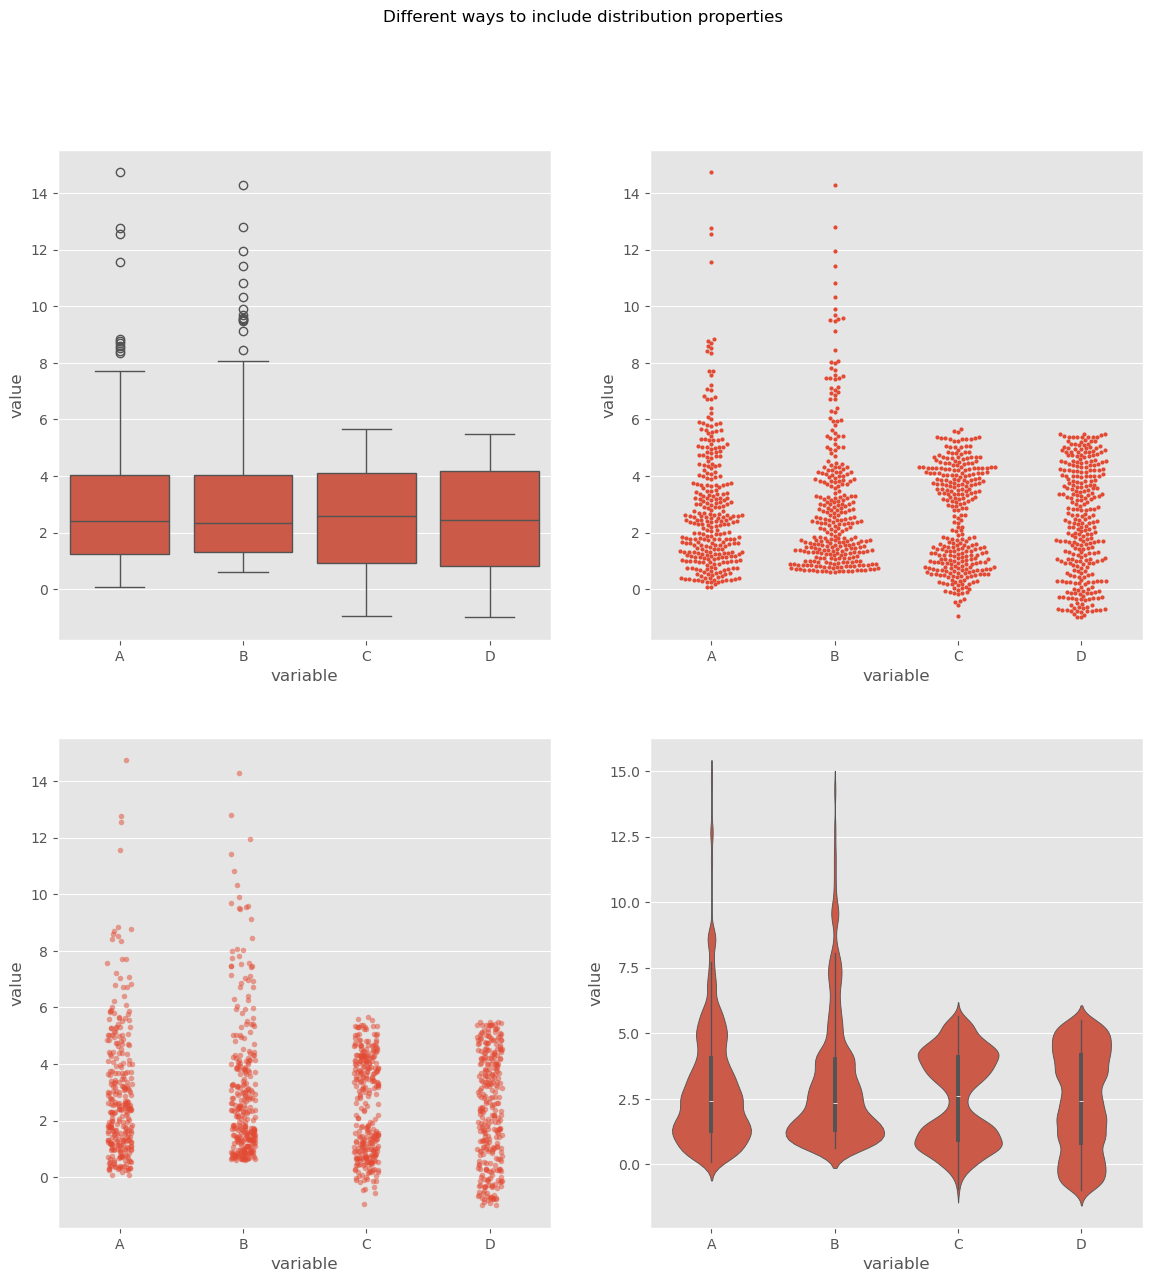

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 14))

sb.boxplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[0][0])

sb.stripplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[1][0], alpha=0.5, size=4)

sb.swarmplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[0][1], size=3)

sb.violinplot(x="variable", y="value", data=pd.melt(datasets_test),
          ax=ax[1][1], bw_method=0.15)  # bw for "bandwidth" controls the degree of smoothing

fig.suptitle("Different ways to include distribution properties")

By utilizing these visualization techniques, we can get a comprehensive understanding of our datasets' distributions and make more informed decisions during analysis.

## Let's talk money

In real life we will come across distributions of all shapes, often non-symmetric. And even though it is considered polite in many cultures to not talk too much about our own wealth and incomes, we all probably know that income and wealth are unlikely to be narrow, symmetric distributions where most people have more or less the same, and earn more or less the same. I will leave the political debates up to you (but I have to confess: I do hope to spark some). 

To me, things like wealth and income are good topics to learn about basic statistics. First, because we all know *something* about money and to some extend care about money (even if we say otherwise). And second, because it is full of striking example of skewed distributions. In fact, let me quote Thomas Piketty here {cite}`piketty_capital_2014`:

>  **Wealth is so concentrated that a large segment of society is virtually unaware of its existence.**


Actual data on incomes in Germany, albeit already evaluated, can be found [here](https://www.destatis.de/DE/Themen/Arbeit/Verdienste/Verdienste-Branche-Berufe/_inhalt.html?templateQueryString=Einkommen).

For raw data requests, you can visit [this site](https://paneldata.org/).

Let's dive into our fictional, but realistic, data. This data is generated based on an actual distribution from Germany in 2025 (see [Link to destatis](https://www.destatis.de/DE/Themen/Arbeit/Verdienste/Verdienste-Branche-Berufe/_inhalt.html#sprg234956)).

In [16]:
# Use real data for a fit, then create dummy/synthetic data following that distribution

import re
from scipy.stats import invgamma
from scipy.optimize import curve_fit

data = pd.read_csv(r"../datasets/verteilung-bruttomonatsverdienste-vollzeitbeschaeftigung_2025.csv", sep=";")

# Rename German columns to English
data = data.rename(columns={
    "Bruttomonatsverdienst": "gross_monthly_income",
    "Anteil": "share"
})

# ============================================================
# Parse data to numerical values (here: statistically not fully correct, but close enough)
# ============================================================

def parse_income(value: str) -> float:
    """
    Convert strings like:
      - "unter 100"            -> 100
      - "11 100 – 11 300"      -> 11200
      - "11 100 - 11 300"      -> 11200
    into numeric values.
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip()
    s = s.replace("\t", " ")
    s = re.sub(r"\s+", " ", s)

    # Case: "unter 100"
    if s.lower().startswith("unter"):
        numbers = re.findall(r"\d+", s)
        if numbers:
            return float(numbers[0])
        return np.nan

    # Case: range like "11 100 – 11 300"
    parts = re.findall(r"\d[\d ]*", s)
    nums = [int(p.replace(" ", "")) for p in parts]

    if len(nums) == 1:
        return float(nums[0])
    elif len(nums) >= 2:
        return float(np.mean(nums[:2]))

    return np.nan


data["gross_monthly_income"] = data["gross_monthly_income"].apply(parse_income)

# ============================================================
# Turn data into pseudo-percentiles
# ============================================================

data = data.sort_values("gross_monthly_income").reset_index(drop=True)
data["probability"] = data["share"] / 100

# midpoint of each class in cumulative probability space
data["cum_probability"] = data["probability"].cumsum()
data["percentile"] = (data["cum_probability"] - data["probability"] / 2) * 100

income_percentiles = data[["percentile", "gross_monthly_income"]].rename(columns={
    "gross_monthly_income": "income"
})


# ============================================================
# Fit inverse gamma to the percentile data
# ============================================================

def fit_invgamma(data_percentiles):
    """
    Fit an inverse gamma distribution to percentile-income pairs.
    """
    df_sorted = data_percentiles.sort_values("percentile").copy()

    probabilities = df_sorted["percentile"].to_numpy() / 100.0
    incomes = df_sorted["income"].to_numpy()

    # Important: keep probabilities away from 0 and 1
    probabilities = np.clip(probabilities, 1e-6, 1 - 1e-6)

    def invgamma_ppf(p, a, scale):
        return invgamma.ppf(p, a, scale=scale)

    initial_guess = [2, 50000]

    params, _ = curve_fit(
        invgamma_ppf,
        probabilities,
        incomes,
        p0=initial_guess,
        bounds=([1e-6, 1e-6], [np.inf, np.inf]),
        maxfev=20000
    )

    fitted_shape, fitted_scale = params
    return fitted_shape, fitted_scale


# ============================================================
# 6) Generate synthetic incomes
# ============================================================

def generate_synthetic_income_data_invgamma(data_percentiles, total_entries):
    fitted_shape, fitted_scale = fit_invgamma(data_percentiles)

    synthetic_incomes = invgamma.rvs(
        fitted_shape,
        scale=fitted_scale,
        size=total_entries
    )
    return synthetic_incomes, (fitted_shape, fitted_scale)


income_simulated, fitted_params = generate_synthetic_income_data_invgamma(
    income_percentiles,
    total_entries=50000
)

income_simulated = pd.DataFrame({
    "gross_monthly_income": income_simulated.astype(np.int32)
})

# show first few entries
income_simulated.head(10)

,gross_monthly_income
0,4613
1,2724
2,5675
3,10226
4,8502
5,8070
6,1631
7,4461
8,3065
9,4337


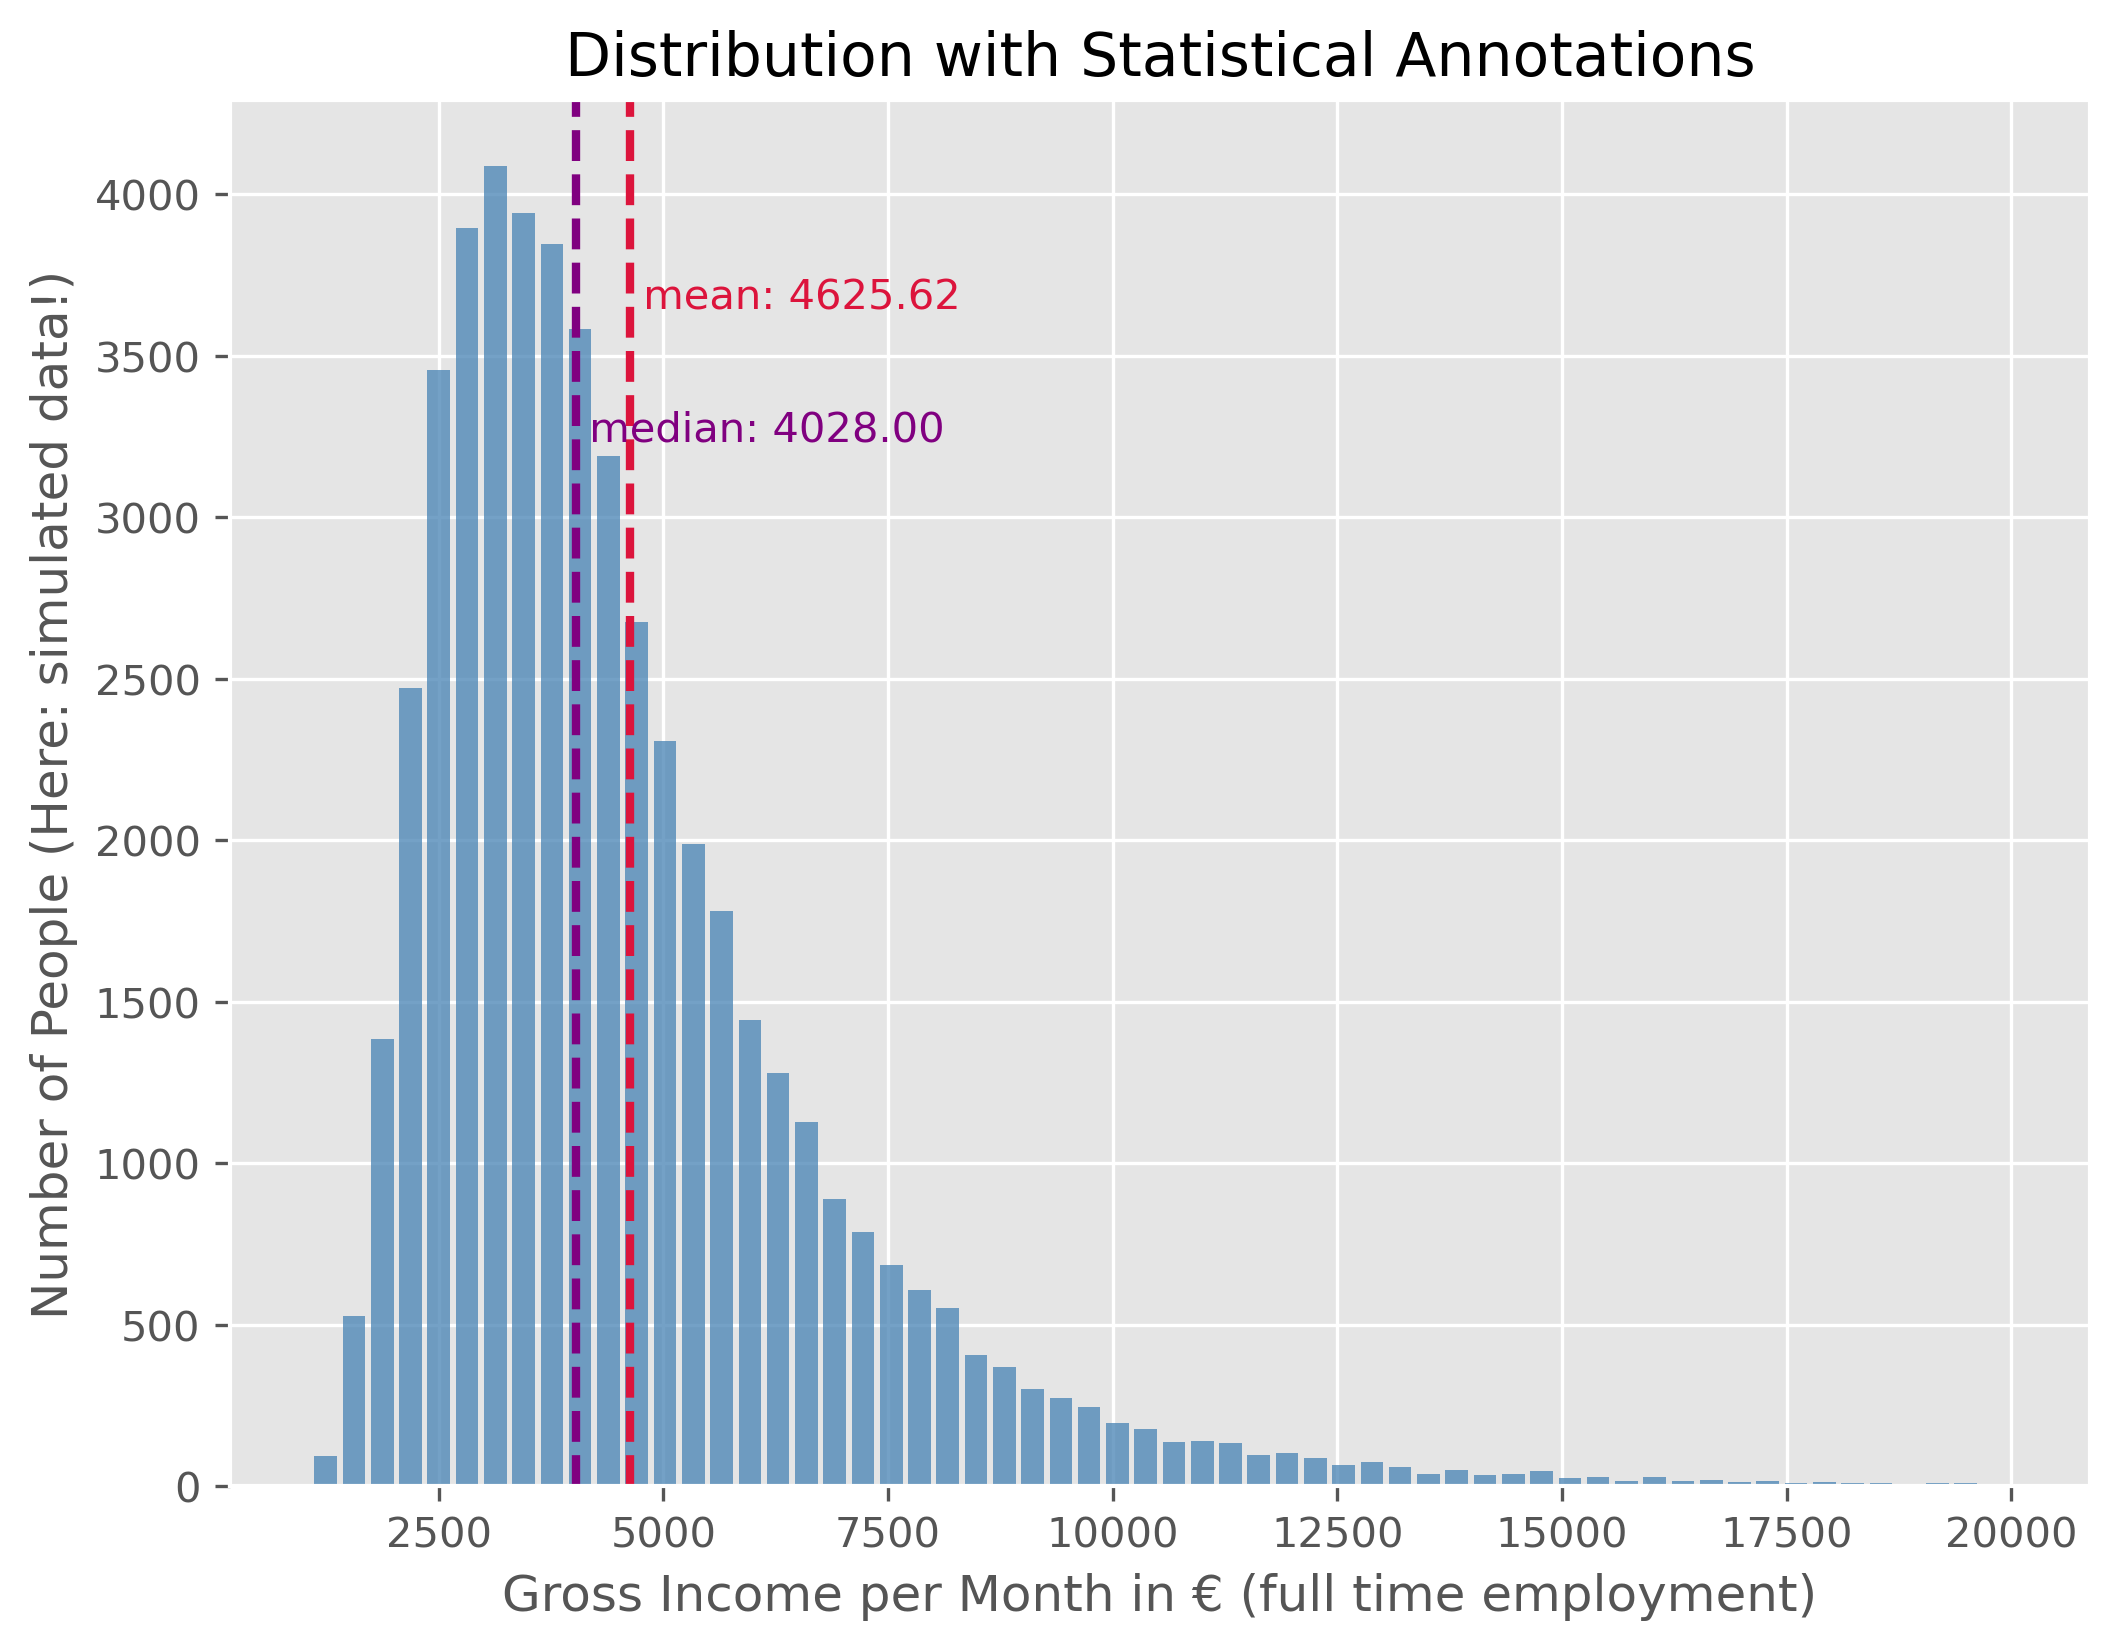

In [17]:
# The visualization will depict income ranges and their frequencies.
plot_dist(income_simulated["gross_monthly_income"], 60, ["mean", "median"], upper_bound=20_000)
plt.ylabel("Number of People (Here: simulated data!)")
plt.xlabel("Gross Income per Month in € (full time employment)")
plt.show()

In [18]:
mean_income = f"{income_simulated["gross_monthly_income"].mean():.2f}"
median_income = f"{income_simulated["gross_monthly_income"].median():.2f}"

This data shows the distribution of monthly gross incomes for people in full-time employment. As expected, this distribution is not symmetric. Instead, it is *right-skewed*, with a long tail to the right, indicating that only *few* people fall into these very high income ranges. For better readability, we use an upper bound of 20,000€ here, even though in reality some people earn substantially more.

As a consequence of the distribution's asymmetry, the mean and the median value are not identical. The **median** income is the value for which 50% of the population earn less and 50% earn more. In this example, the **median** gross monthly income is **€{eval}`median_income`**. The **mean** income is higher, at **€{eval}`mean_income`**, because a small number of very high incomes pull the average upward.

As a reminder, this is synthetic data, but the resulting values are quite close to the real ones.

#### Boxplot and Violinplot
We have just seen before that there are different ways to visualize distributions. In addition to the *histogram plot* that we just did, we can also try to again use a *box plot* or *violin plot*.

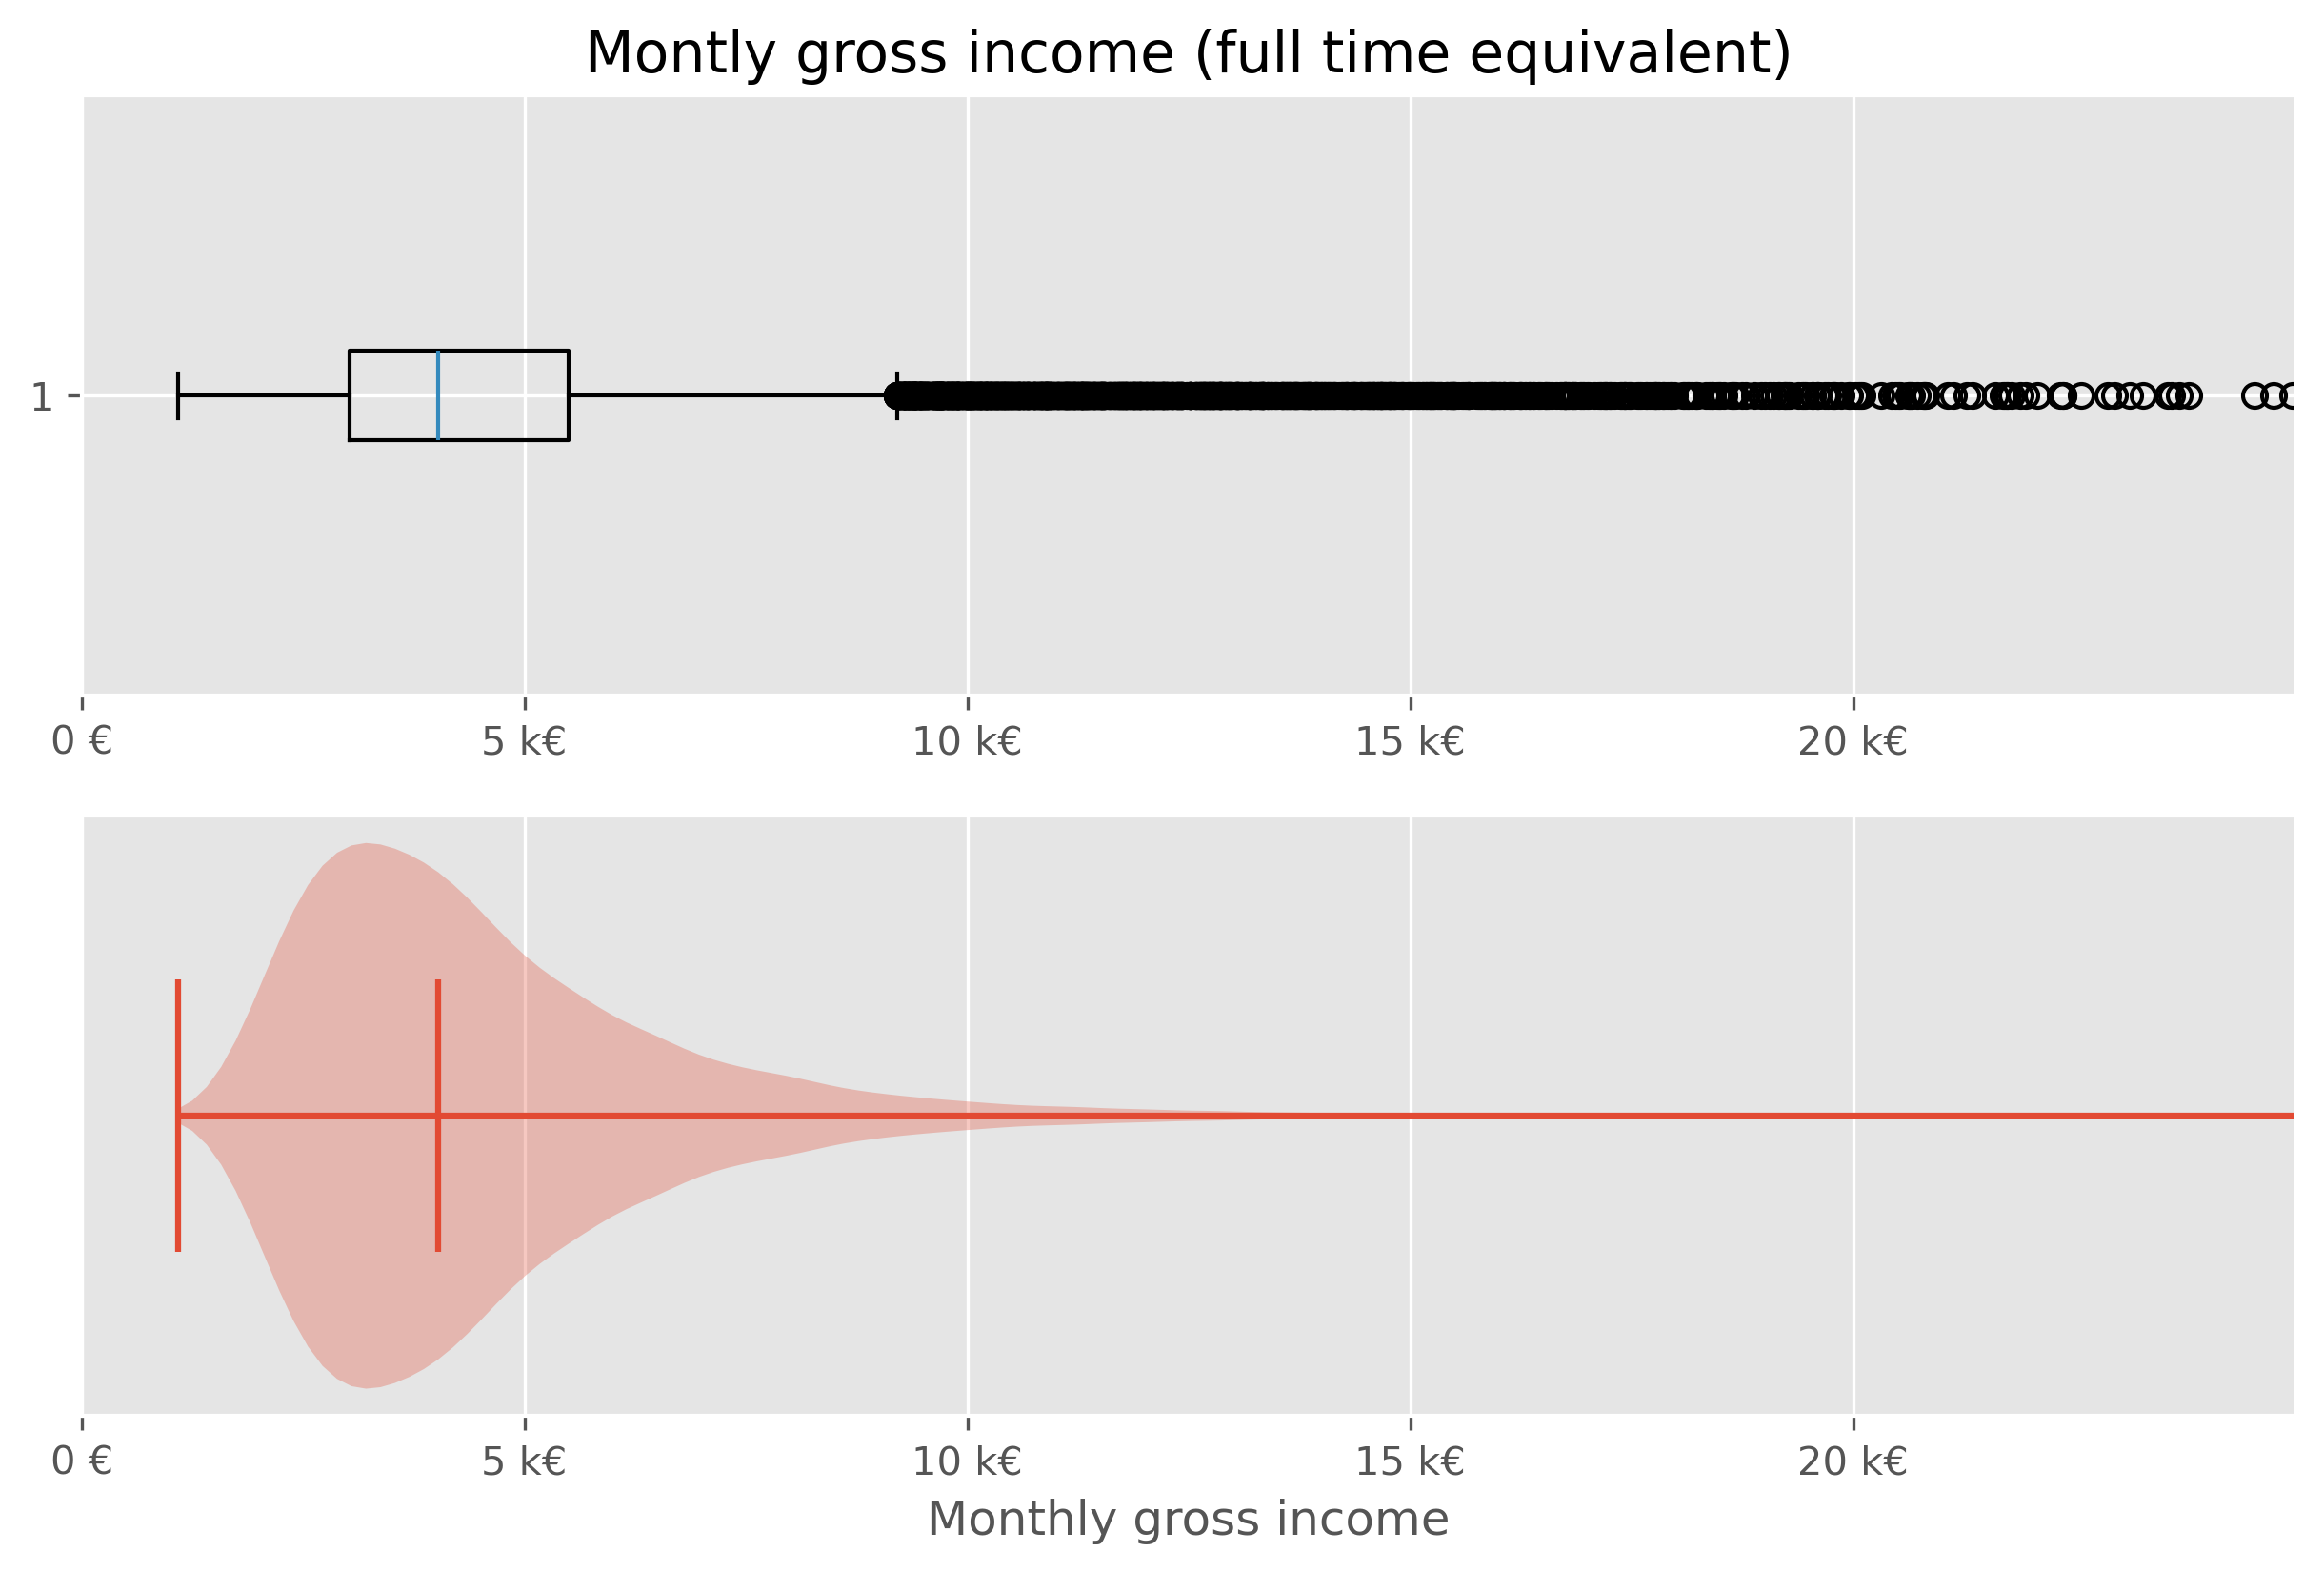

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=300)

axes[0].set_title("Montly gross income (full time equivalent)")

# Plot 1 - Boxplot
axes[0].boxplot(income_simulated["gross_monthly_income"], vert=False)
axes[0].set_xlim(0, 25_000)
#axes[0].set_xlabel("Monthly gross income")
axes[0].set_xticks(ticks = [0, 5000, 1e4, 1.5e4, 2e4],
              labels=["0 €", "5 k€","10 k€", "15 k€", "20 k€"])

# Plot 2 - Violinplot
axes[1].violinplot(income_simulated["gross_monthly_income"], vert=False,
                   points=300,
                   showmedians=True)
axes[1].set(yticks=[])
axes[1].set_xlim(0, 25_000)
axes[1].set_xlabel("Monthly gross income")
axes[1].set_xticks(ticks = [0, 5000, 1e4, 1.5e4, 2e4],
              labels=["0 €", "5 k€","10 k€", "15 k€", "20 k€"])

plt.show()

While both types of plots work from a technical point of few, they are not ideal in this situations. The main issue here is, that the largest part of the figure essential shows virtually nothing (violin plot), or nothing readable (box plot).

Specifically in cases like this, it is often helpful to work with percentiles (or deciles, quintiles...).

In [20]:
# Code to compute and display quantiles of the income data
income_simulated.quantile(q=np.arange(0, 1.1, 0.1))

,gross_monthly_income
0.0,1086.0
0.1,2396.0
0.2,2831.0
0.3,3219.0
0.4,3614.0
0.5,4028.0
0.6,4498.0
0.7,5108.3
0.8,5968.2
0.9,7488.0


We can further dissect this data by dividing it into deciles:

In [21]:
income_simulated["decile"] = pd.qcut(income_simulated['gross_monthly_income'], q=10, labels=np.arange(10))
income_simulated.head()

,gross_monthly_income,decile
0,4613,6
1,2724,1
2,5675,7
3,10226,9
4,8502,9


Visualizing median income for each decile:

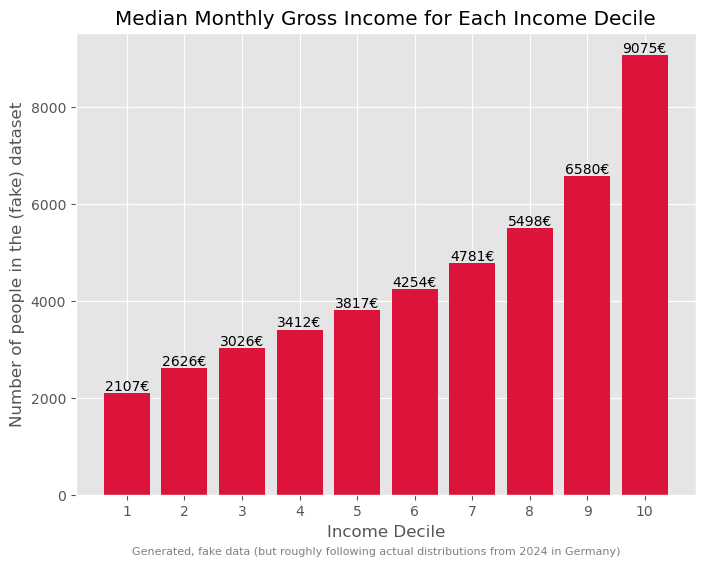

In [22]:
# Code to visualize the median income for each decile

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(
    x=np.arange(10),
    height=income_simulated.groupby("decile", observed=True).median()["gross_monthly_income"],
    color="crimson",
    )
for i, v in enumerate(income_simulated.groupby("decile", observed=True).median()["gross_monthly_income"]):
    ax.text(i, v + 50, f"{v:.0f}€", color='black', ha="center")

ax.set_xticks(ticks=np.arange(10), labels=np.arange(1,11), rotation=0)
ax.set_xlabel("Income Decile")
ax.set_ylabel("Number of people in the (fake) dataset")
ax.set_title("Median Monthly Gross Income for Each Income Decile")
fig.text(
    0.5, 0.01,
    "Generated, fake data (but roughly following actual distributions from 2024 in Germany)", 
    ha="center", fontsize=8, color="gray"
)

plt.show()

Such a breakdown offers more insights into the income disparities.

In [23]:
# Code to determine and display the total income for each decile
income_sum = income_simulated.groupby("decile", observed=True).sum()
income_sum["gross_monthly_income"] *= 100 / income_sum["gross_monthly_income"].sum()
income_sum

,gross_monthly_income
decile,
0,4.449645
1,5.651497
2,6.544680
3,7.378542
4,8.252477
5,9.214879
6,10.334790
7,11.915484
8,14.339474


This can be further visualized using a **treemap**, which is an alternative way to visualize fractions. 

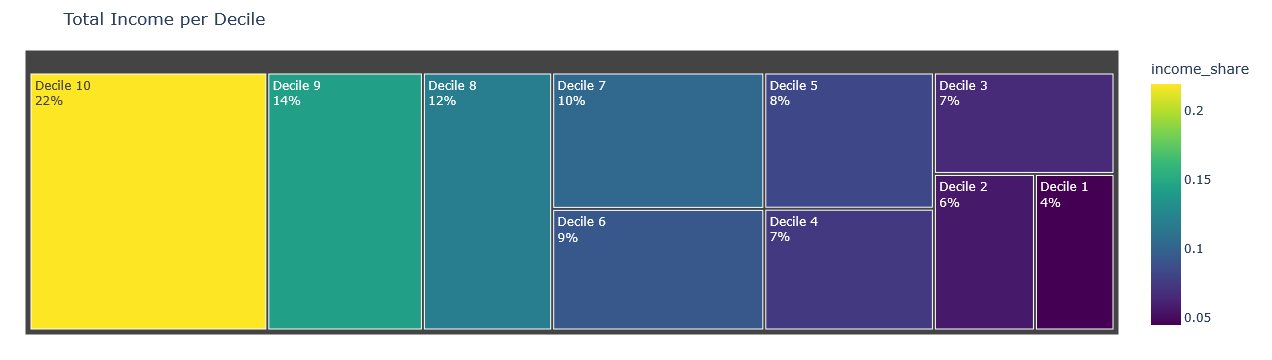

In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

# Prepare data for plotting
income_treemap_data = income_sum.copy().reset_index(drop=True)
income_treemap_data["Decile"] = [f"Decile {i+1}" for i in range(len(income_treemap_data))]
income_treemap_data["income_share"] = (
    income_treemap_data["gross_monthly_income"] / income_treemap_data["gross_monthly_income"].sum()
)

fig = px.treemap(
    income_treemap_data,
    path=["Decile"],
    values="income_share",
    color="income_share",
    color_continuous_scale="Viridis",
    title="Total Income per Decile"
)

fig.update_traces(
    textinfo="label+percent entry",
    hovertemplate="<b>%{label}</b><br>Income share: %{value:.2%}<extra></extra>"
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig

### Wealth

Typically, as the Piketty quote earlier on also said, wealth has a much more skewed distribution than income!

Here, we will again work with generated, but realistic, data.
The underlying distribution is from a 2023 census done by the "Bundesbank", the central bank of Germany (see [link to website](https://publikationen.bundesbank.de/publikationen-de/berichte-studien/monatsberichte/monatsbericht-april-2025-954594?article=vermoegen-und-finanzen-privater-haushalte-in-deutschland-ergebnisse-der-vermoegensbefragung-2023--954598)).

While general trends typically agree, many specific numbers in such financial reports and datasets will vary greatly. This is caused by different methodologies. The Bundesbank data, for instance, is based on information received by about 5,000 randomly selected, voluntary participants. Give the very few super-rich people in the population, the group of the richtest people is likely underestimated/under-represented here. Also, people might judge their wealth too high or low.

In [25]:
distribution_germany = pd.DataFrame({
    "percentile": [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95],
    "mean": [-800, 800, 7100, 19100, 49300, 103200, 196100, 326200, 473500, 779500, 1227900],
})

distribution_germany["group_size_percent"] = (
    distribution_germany["percentile"].diff().fillna(distribution_germany["percentile"])
)

distribution_germany

,percentile,mean,group_size_percent
0,5,-800,5.0
1,10,800,5.0
2,20,7100,10.0
3,30,19100,10.0
4,40,49300,10.0
5,50,103200,10.0
6,60,196100,10.0
7,70,326200,10.0
8,80,473500,10.0
9,90,779500,10.0


#### Generation of synthetic (but generally realistic) wealth data

In [26]:
def generate_wealth_data(data, total_entries, random_state=None):
    """I am pretty sure that this function is nothing economists would be willing to accept.
    It is far too simple, but it will be sufficient for getting a sense of this type of
    data and it reproduces general trends in the data (as far as we even know, because data
    on wealth is inherently sparse and difficult to get and to check!).
    """
    rng = np.random.default_rng(random_state)
    synthetic_data = []

    # Convert percentile group widths into counts
    counts = np.round(data["group_size_percent"] / 100 * total_entries).astype(int)
    counts.iloc[-1] += total_entries - counts.sum()

    for (_, row), count in zip(data.iterrows(), counts):
        mean = row["mean"]

        if count <= 0:
            continue

        # Very simple classroom approximation:
        # use a normal distribution around the group mean
        std_dev = max(abs(mean) / 2, 500)

        generated = rng.normal(loc=mean, scale=std_dev, size=count)
        synthetic_data.extend(generated)

    synthetic_data = np.array(synthetic_data)
    
    # manual corrections to make it more realistic
    synthetic_data[synthetic_data < 0] *=0.25  # was to drastic before

    super_super_rich = int(np.ceil(total_entries / 10_000))
    synthetic_data[-super_super_rich:] = 250_000_000
    
    return np.array(synthetic_data)

In [27]:
synthetic_wealth_data = generate_wealth_data(distribution_germany, 50_000, random_state=42)

Such wealth distributions, particularly when skewed, might be challenging to interpret directly. Different visual representations can offer distinct perspectives:

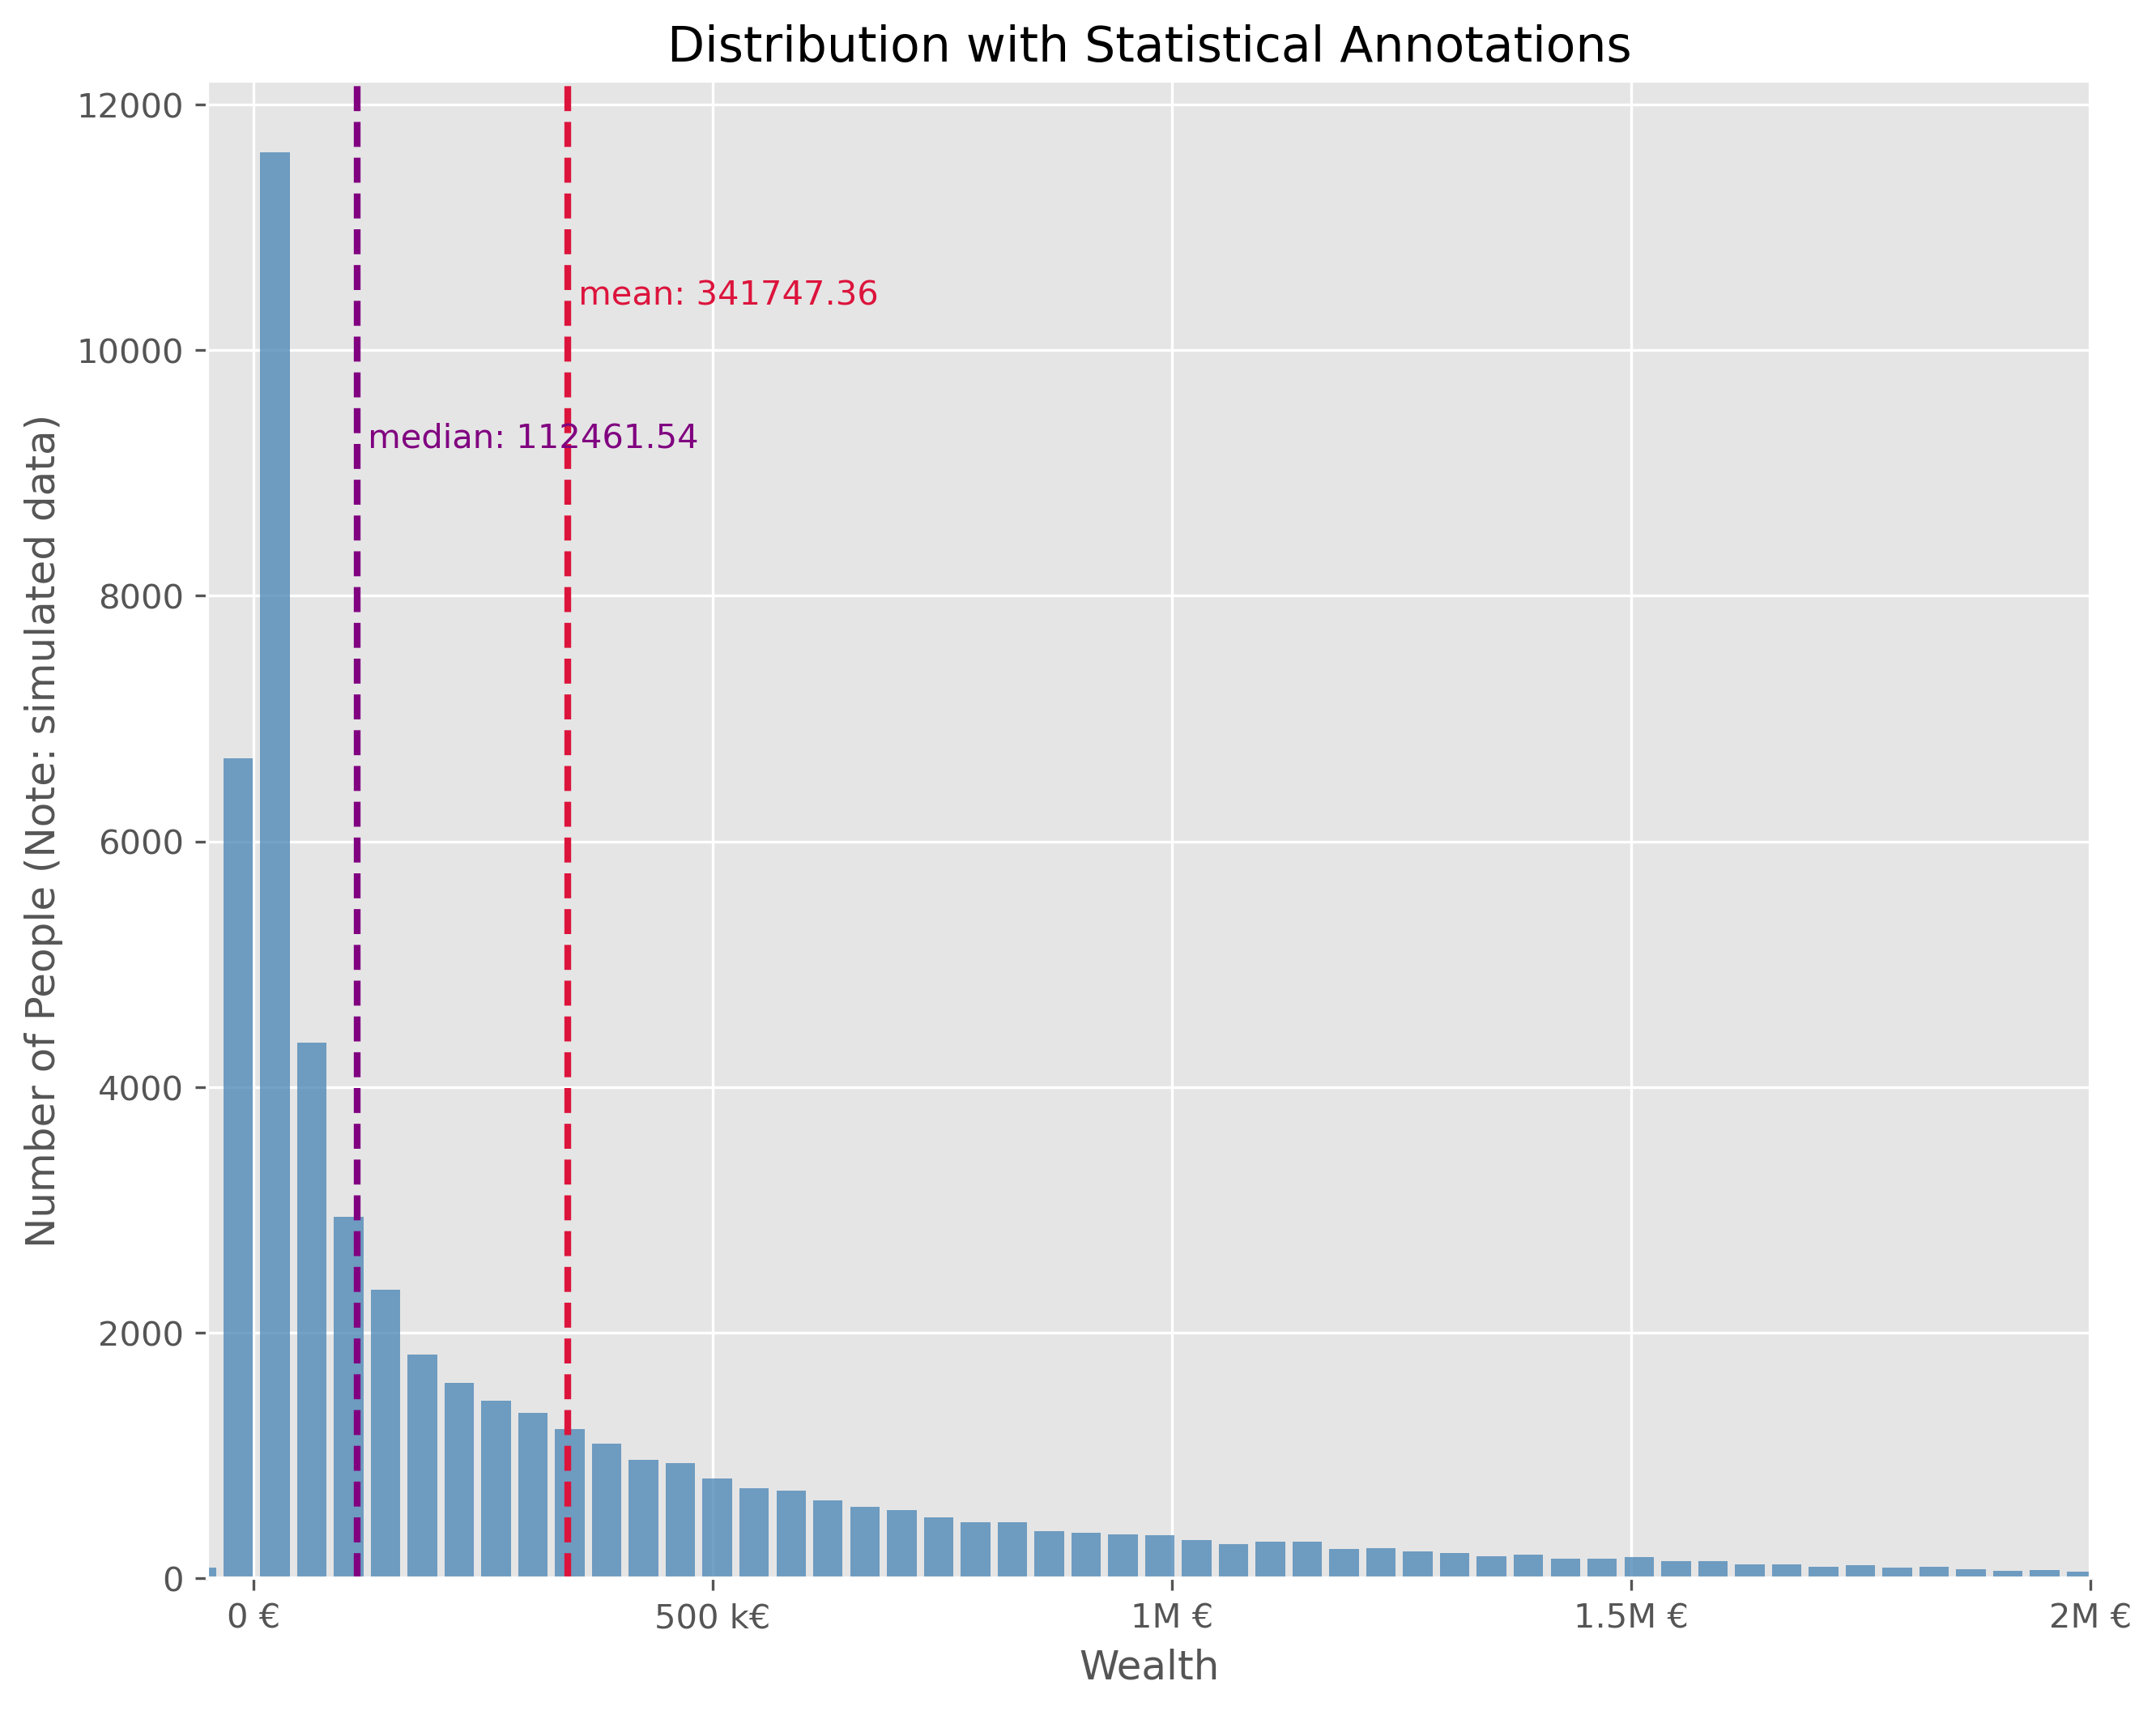

In [28]:
plot_dist(
    synthetic_wealth_data, 100,
    ["mean", "median"],
    upper_bound=5_000_000,
    figsize=(10,8)
)
plt.xlim(-50000, 2e6)
plt.xlabel("Wealth")
plt.ylabel("Number of People (Note: simulated data)")
plt.xticks(ticks = [0, 5e5, 1e6, 1.5e6, 2e6], labels=["0 €", "500 k€",
                                                     "1M €", "1.5M €", "2M €"])
plt.show()

This plot is technically OK. But is has a number of disadvantages. It is visually very centered on the left side due to the strong asymmetry in the wealth distribution. This also leads to the fact, that the *long tail*, that is all the fortunes above > 500k€ are practically impossible to read in this plot. We can try different plot types.

We will quickly see, that neither a **box plot** nor a **violin plot** is not making things better here:

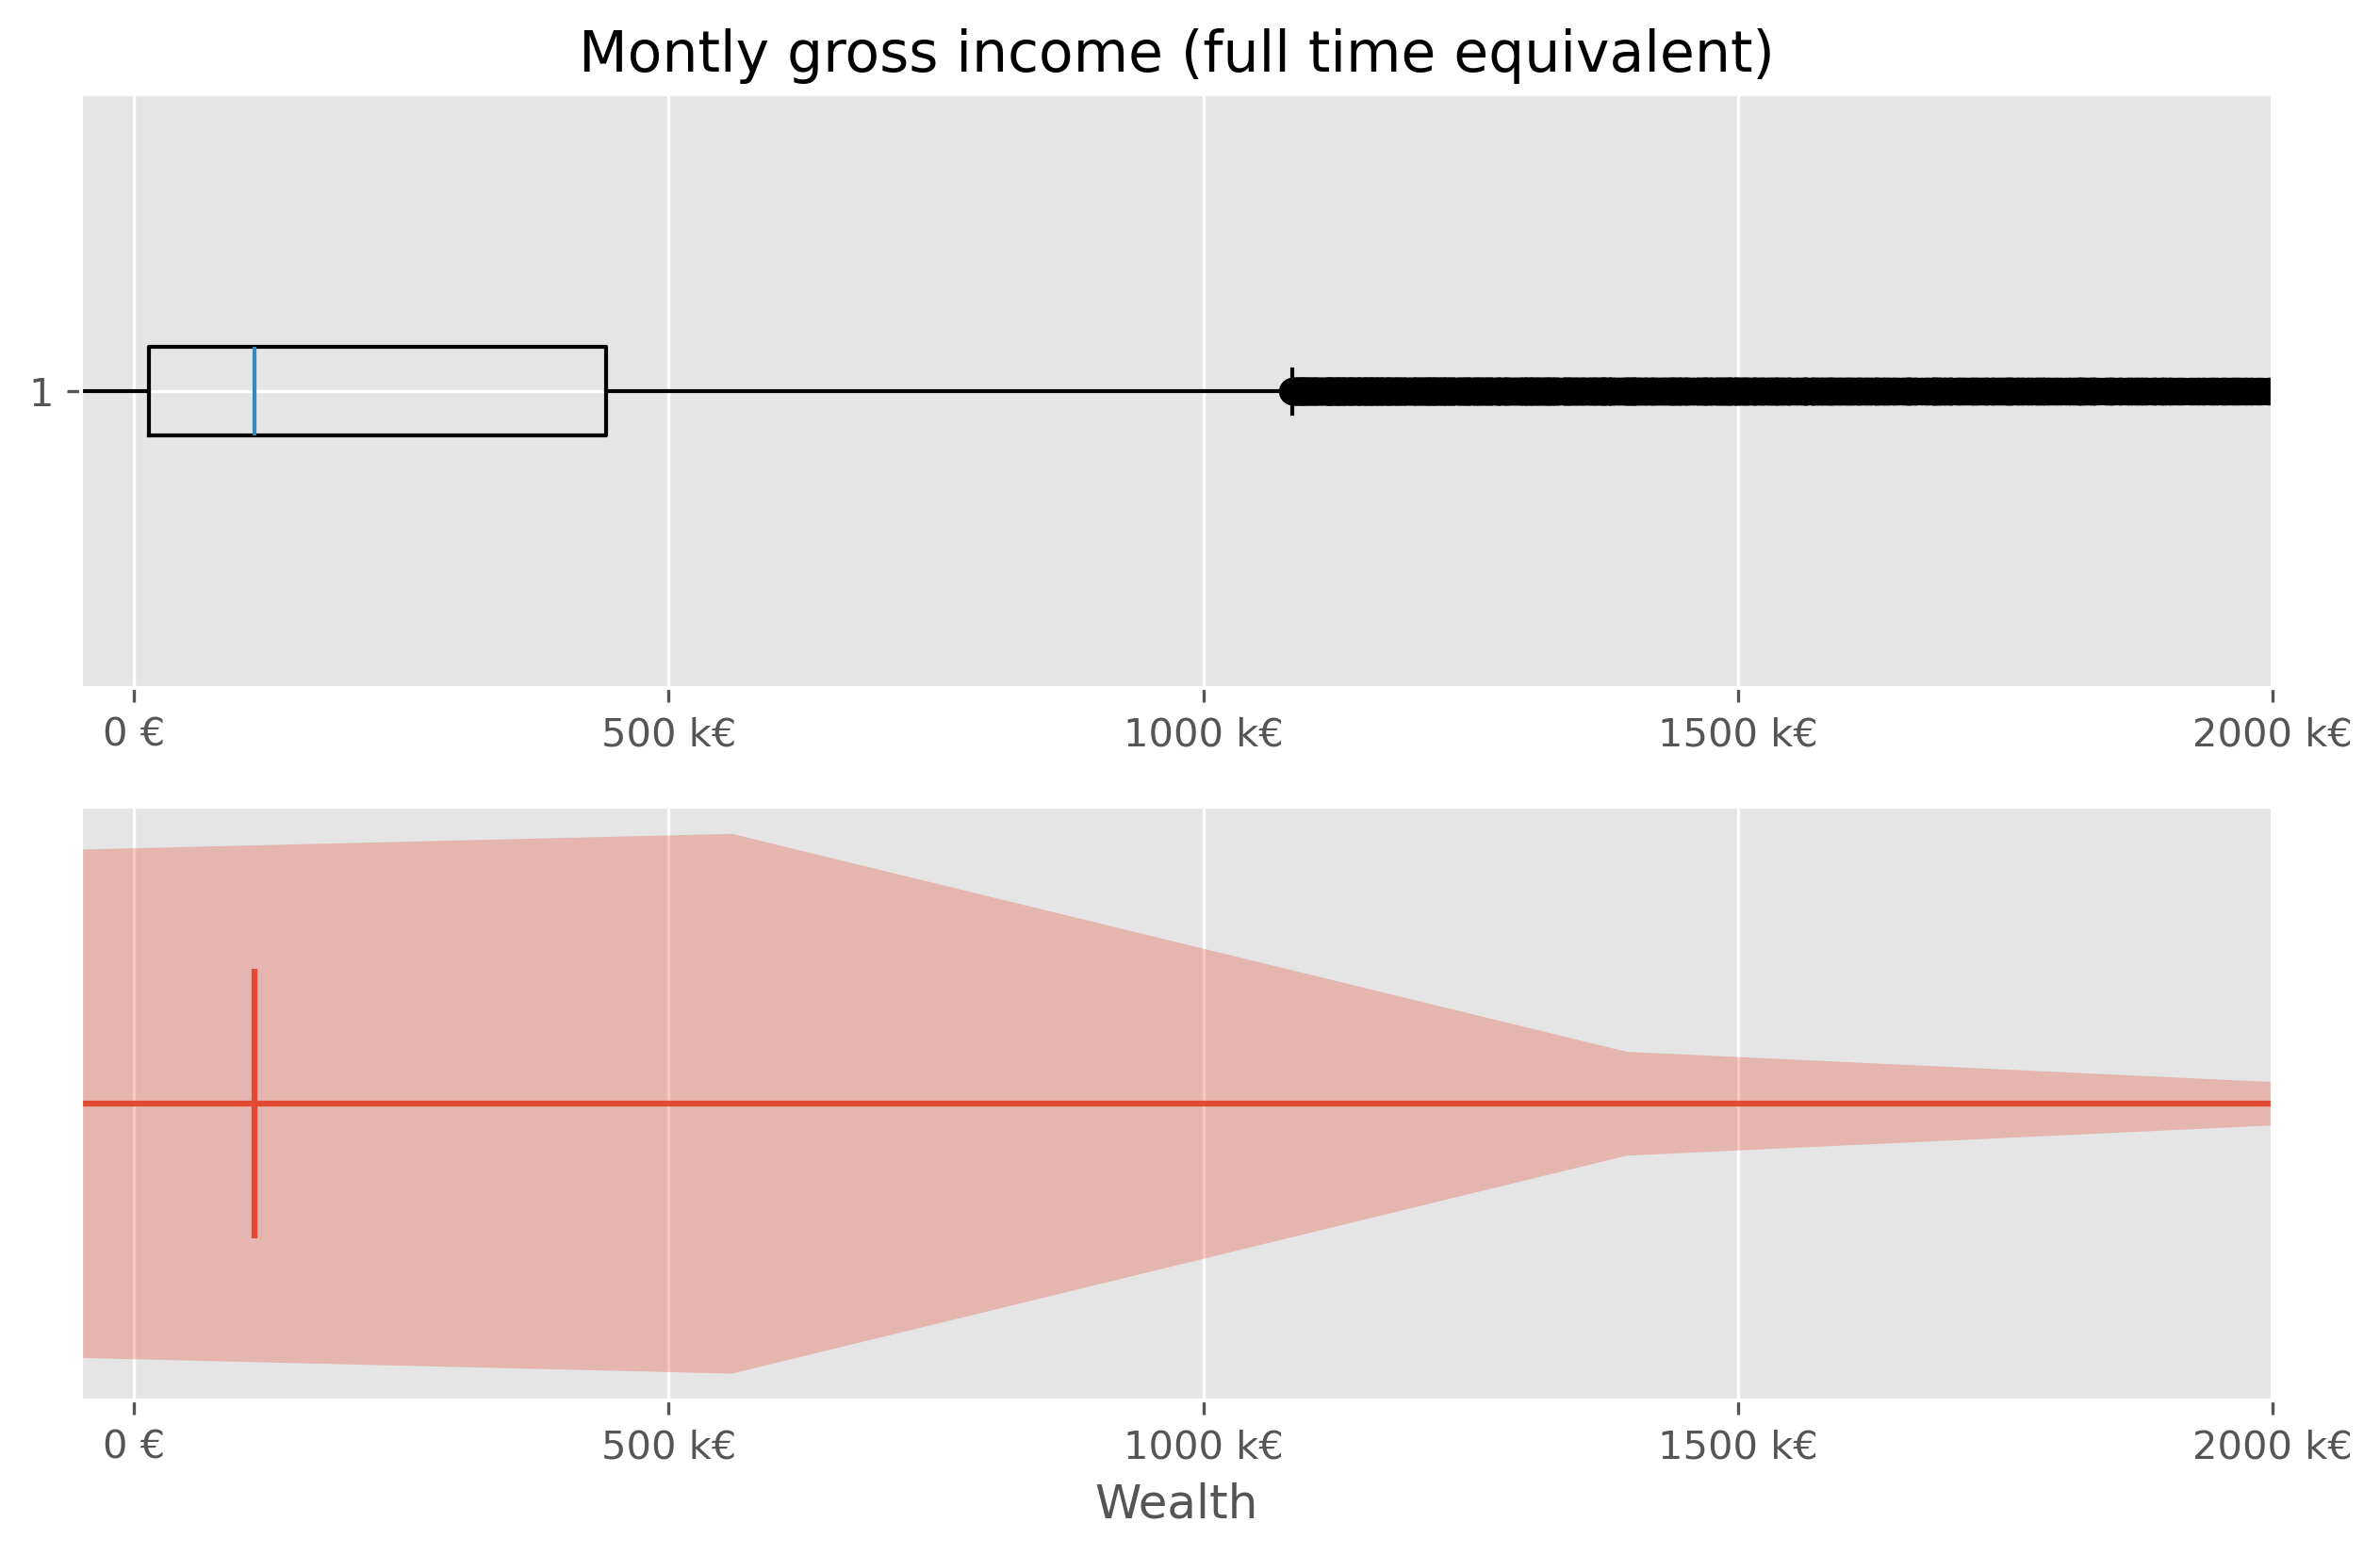

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=300)

axes[0].set_title("Montly gross income (full time equivalent)")

# Plot 1 - Boxplot
axes[0].boxplot(synthetic_wealth_data, vert=False)
axes[0].set_xlim(-50000, 2e6)
axes[0].set_xticks(ticks = [0, 5e5, 1e6, 1.5e6, 2e6],
              labels=["0 €", "500 k€","1000 k€", "1500 k€", "2000 k€"])

# Plot 2 - Violinplot
axes[1].violinplot(synthetic_wealth_data, vert=False,
                   points=300,
                   showmedians=True)
axes[1].set(yticks=[])
axes[1].set_xlim(-50000, 2e6)
axes[1].set_xlabel("Wealth")
axes[1].set_xticks(ticks = [0, 5e5, 1e6, 1.5e6, 2e6],
              labels=["0 €", "500 k€","1000 k€", "1500 k€", "2000 k€"])

plt.show()

Sometimes it helps to switch from a linear to a logarithmic scale. Not in this case though:

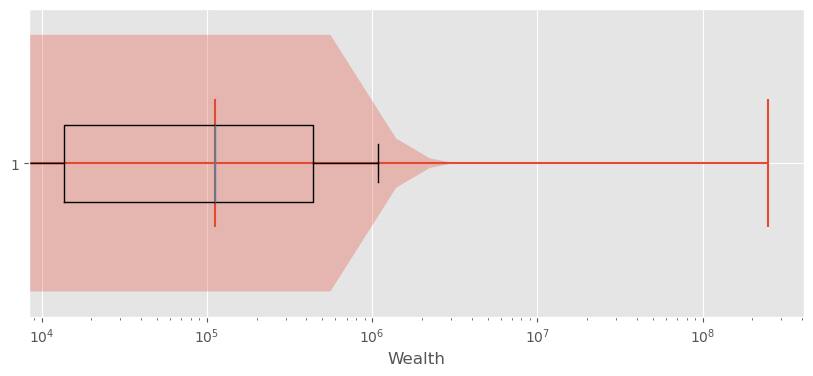

In [30]:
fig, ax = plt.subplots(figsize=(10,4))
ax.violinplot(synthetic_wealth_data, vert=False, points=300,
             showmedians=True)
ax.boxplot(synthetic_wealth_data, vert=False, showfliers=False)
ax.set_ylim(0.7, 1.3)
ax.set_xlabel("Wealth")
ax.set_xticks(ticks = [0, 5e5, 1e6, 1.5e6, 2e6],
              labels=["0 €", "500 k€", "1000 k€", "1500 k€", "2000 k€"])
ax.set_xscale("log")
plt.show()

### Exploring Wealth Distribution: A Different Approach

Analyzing wealth distribution can be quite abstract due to the vast range of values we might encounter. Even switching to non-linear scales is not overly satisfying here. Here, two difficulties come together. First, the distribution is heavily skewed and second, wealth can also take negative values (unfortunately for many...).

Just as with the incomes, one effective way to dissect this vastness is by segmenting it into more digestible chunks, like deciles.

In principle, this could be computed via  
`wealth_data["decile"] = pd.qcut(wealth_data['wealth'], q=10, labels=np.arange(10))`  
But to avoid using the simulated data, we can use actual data at this point.

In [31]:
wealth_df = pd.DataFrame({"wealth": synthetic_wealth_data})
wealth_df = wealth_df.sort_values("wealth").reset_index(drop=True)

wealth_df["percentile_rank"] = wealth_df["wealth"].rank(method="first", pct=True)

wealth_df["decile"] = pd.cut(
    wealth_df["percentile_rank"],
    bins=np.linspace(0, 1, 11),
    labels=[
        "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
        "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"
    ],
    include_lowest=True
)

wealth_germany_data = (
    wealth_df.groupby("decile", observed=False)["wealth"]
    .mean()
    .reset_index(name="mean_wealth")
)

Such data (percentiles, deciles etc.) can often be plotted fairly well as a bar plot.

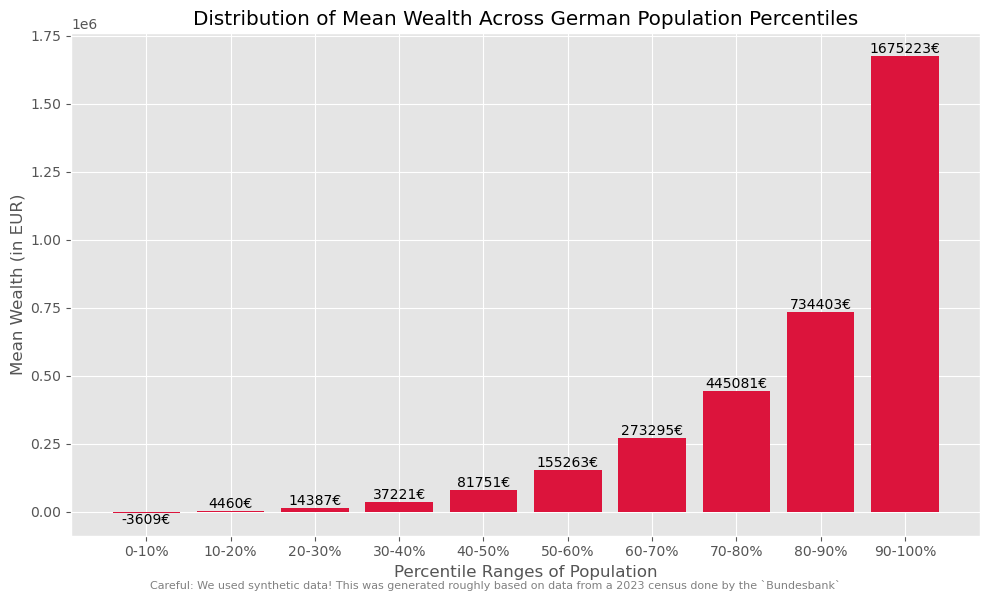

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    wealth_germany_data.index,
    wealth_germany_data["mean_wealth"],
    color="crimson",
)

for bar, wealth in zip(bars, wealth_germany_data["mean_wealth"]):
    yval = bar.get_height()
    va = "bottom" if yval >= 0 else "top"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval,
        f"{wealth:.0f}€",
        ha="center",
        va=va
    )

ax.set_xlabel("Percentile Ranges of Population")
ax.set_ylabel("Mean Wealth (in EUR)")
ax.set_title("Distribution of Mean Wealth Across German Population Percentiles")

ax.set_xticks(wealth_germany_data.index)
ax.set_xticklabels(wealth_germany_data["decile"])

ax.grid(True, axis="y")
fig.text(
    0.5, 0.01,
    "Careful: We used synthetic data! This was generated roughly based on data from"\
    " a 2023 census done by the `Bundesbank`", 
    ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

But if we wish to amplify the impact of these insights visually, we can take a more graphical approach. This can, for instance be done using a so called *treemap plot*.

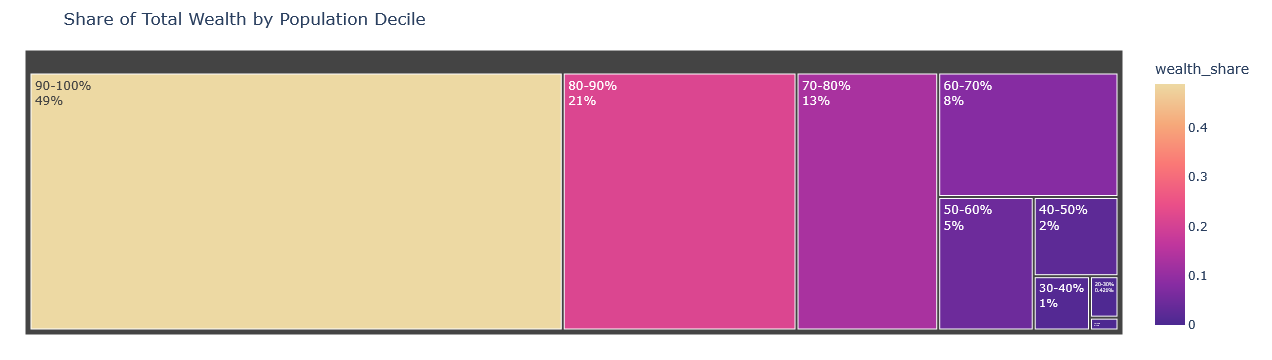

In [ ]:
import plotly.express as px

# Aggregate wealth by decile
wealth_share_data = (
    wealth_df.groupby("decile", observed=False)["wealth"]
    .sum()
    .reset_index(name="wealth_sum")
)

# Convert to share of total wealth
wealth_share_data["wealth_share"] = (
    wealth_share_data["wealth_sum"] / wealth_share_data["wealth_sum"].sum()
)

wealth_share_data = wealth_share_data.rename(columns={
    "decile": "Percentile"
})

fig = px.treemap(
    wealth_share_data,
    path=["Percentile"],
    values="wealth_share",
    color="wealth_share",
    color_continuous_scale="Agsunset",
    title="Share of Total Wealth by Population Decile"
)

fig.update_traces(
    textinfo="label+percent entry",
    hovertemplate="<b>%{label}</b><br>Wealth share: %{value:.2%}<extra></extra>"
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig

It is often a good thing to work with consistent "bins", meaning a division of the data into subsets of equal size (here into 10 subsets, each representing 10% of the population). But sometimes it can help to choose differen splits to highlight particular biases or extremes. Here, for instance, it may help to combine the lower-wealth-half of the population (0-50%) to strenghten the picture and to avoid the issue with negative values.

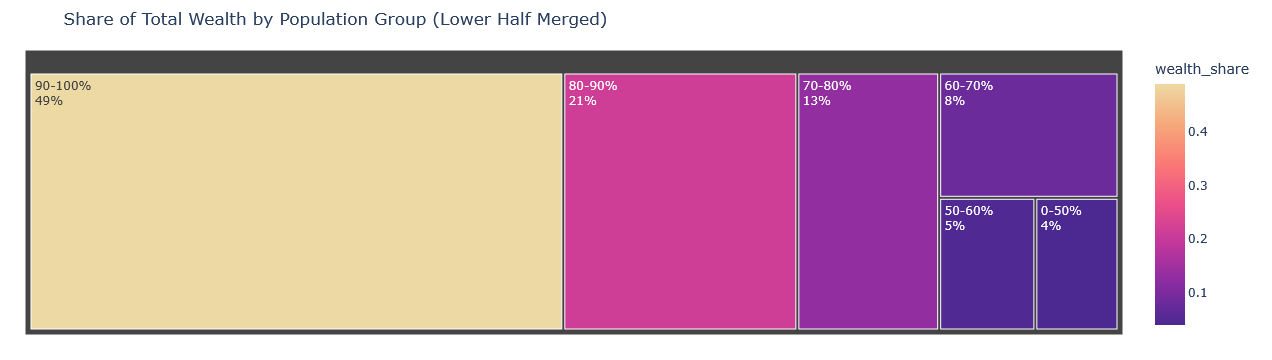

In [34]:
# Create merged groups for a second visualization
wealth_df["treemap_group"] = wealth_df["decile"].astype(str).replace({
    "0-10%": "0-50%",
    "10-20%": "0-50%",
    "20-30%": "0-50%",
    "30-40%": "0-50%",
    "40-50%": "0-50%",
})

wealth_share_merged = (
    wealth_df.groupby("treemap_group")["wealth"]
    .sum()
    .reset_index(name="wealth_sum")
)

wealth_share_merged["wealth_share"] = (
    wealth_share_merged["wealth_sum"] / wealth_share_merged["wealth_sum"].sum()
)

wealth_share_merged = wealth_share_merged.rename(columns={
    "treemap_group": "Percentile"
})

group_order = ["0-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
wealth_share_merged["Percentile"] = pd.Categorical(
    wealth_share_merged["Percentile"],
    categories=group_order,
    ordered=True
)
wealth_share_merged = wealth_share_merged.sort_values("Percentile")

fig = px.treemap(
    wealth_share_merged,
    path=["Percentile"],
    values="wealth_share",
    color="wealth_share",
    color_continuous_scale="Agsunset",
    title="Share of Total Wealth by Population Group (Lower Half Merged)"
)

fig.update_traces(
    textinfo="label+percent entry",
    hovertemplate="<b>%{label}</b><br>Wealth share: %{value:.2%}<extra></extra>"
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

Yet another modification that we could do here is to zoom in a bit more on the top-10% of the most wealthy part of the population. It is important to remind that the data I use in this notebook is **generated** based on some basic statistical values from a subsample of the population. We hence do not work with **real** data. More than that, getting actual data on wealth is a topic on its own [see Wikipedia](https://de.wikipedia.org/wiki/Verm%C3%B6gensverteilung_in_Deutschland) {cite}`piketty_capital_2014, linartas_unverdiente_2025, zucman_reichensteuer_2026`! First of all, many people do not want to share those values. And since we have no tax on wealth in Germany, people also don't have to. And, secondly, the enormous bias in the distribution means that we will easily find people with a wealth of a few hundred thousand euros in a subsample of the population, but the more we move to the richest people, the fewer this will be. On the extreme end of the scale, we are talking about a really small circle.

I tried to make the data in this notebook *more-or-less* realistic. Many estimates assume an even more drastic long tail of the distribution, see also [Wikipedia](https://de.wikipedia.org/wiki/Verm%C3%B6gensverteilung_in_Deutschland).

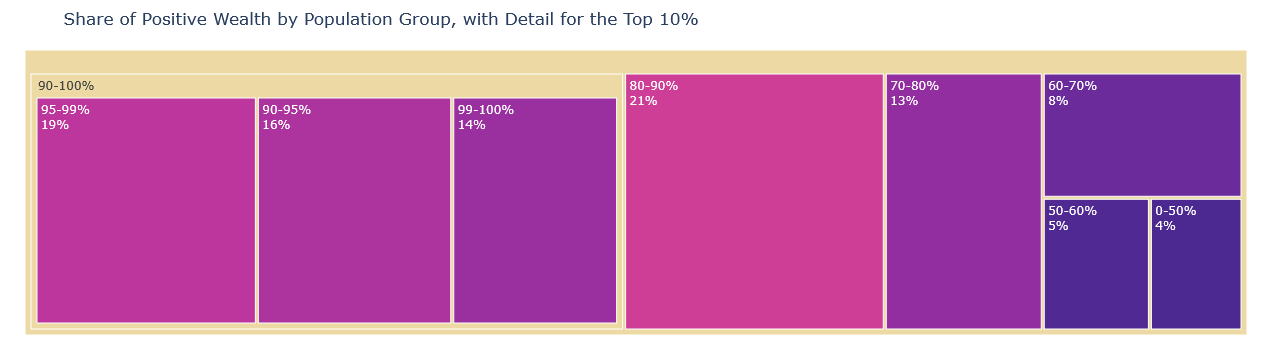

In [35]:
import plotly.graph_objects as go
from matplotlib import colors as mcolors


# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

wealth_detail_df = wealth_df[["wealth"]].copy()
wealth_detail_df = wealth_detail_df.sort_values("wealth").reset_index(drop=True)
wealth_detail_df["percentile_rank"] = (wealth_detail_df.index + 1) / len(wealth_detail_df)

# Main groups: lower half merged
wealth_detail_df["group"] = pd.cut(
    wealth_detail_df["percentile_rank"],
    bins=[0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=["0-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"],
    include_lowest=True
).astype(str)

# Split the top 10% further
top_mask = wealth_detail_df["percentile_rank"] > 0.9
wealth_detail_df.loc[top_mask, "top_subgroup"] = pd.cut(
    wealth_detail_df.loc[top_mask, "percentile_rank"],
    bins=[0.9, 0.95, 0.99, 1.0],
    labels=["90-95%", "95-99%", "99-100%"],
    include_lowest=True
).astype(str)


# ------------------------------------------------------------
# Aggregate wealth by main group
# ------------------------------------------------------------

group_sums = (
    wealth_detail_df.groupby("group", observed=False)["wealth"]
    .sum()
    .reset_index(name="wealth_sum")
)

# Keep only positive groups
group_sums = group_sums[group_sums["wealth_sum"] > 0].copy()

# Use only positive wealth for treemap shares
positive_total = group_sums["wealth_sum"].sum()
group_sums["wealth_share"] = group_sums["wealth_sum"] / positive_total


# ------------------------------------------------------------
# Aggregate top subgroups
# ------------------------------------------------------------

top_sums = (
    wealth_detail_df.loc[top_mask]
    .groupby("top_subgroup", observed=False)["wealth"]
    .sum()
    .reset_index(name="wealth_sum")
)

top_sums = top_sums[top_sums["wealth_sum"] > 0].copy()
top_sums["wealth_share"] = top_sums["wealth_sum"] / positive_total


# ------------------------------------------------------------
# Build treemap hierarchy
# ------------------------------------------------------------

labels = [""]
ids = ["all"]
parents = [""]
values = [1.0]
shares_for_color = [1.0]

# Add all main groups except 90-100 as leaf nodes
for _, row in group_sums[group_sums["group"] != "90-100%"].iterrows():
    labels.append(row["group"])
    ids.append(row["group"])
    parents.append("all")
    values.append(row["wealth_share"])
    shares_for_color.append(row["wealth_share"])

# Add 90-100 as parent node
top_row = group_sums[group_sums["group"] == "90-100%"]
if not top_row.empty:
    top_total_share = top_row["wealth_share"].iloc[0]

    labels.append("90-100%")
    ids.append("90-100%")
    parents.append("all")
    values.append(top_total_share)
    shares_for_color.append(top_total_share)

    # Add children inside 90-100
    for _, row in top_sums.iterrows():
        labels.append(row["top_subgroup"])
        ids.append(row["top_subgroup"])
        parents.append("90-100%")
        values.append(row["wealth_share"])
        shares_for_color.append(row["wealth_share"])


# ------------------------------------------------------------
# Explicit colors
# ------------------------------------------------------------

colorscale = px.colors.get_colorscale("Agsunset")

min_share = min(shares_for_color[1:])
max_share = max(shares_for_color[1:])
norm = mcolors.Normalize(vmin=min_share, vmax=max_share)

node_colors = []
for share in shares_for_color:
    x = norm(share)
    x = np.clip(x, 1e-6, 1 - 1e-6)
    node_colors.append(px.colors.sample_colorscale(colorscale, [x])[0])


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = go.Figure(go.Treemap(
    labels=labels,
    ids=ids,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(colors=node_colors),
    textinfo="label+percent entry",
    hovertemplate="<b>%{label}</b><br>Share of positive wealth: %{value:.2%}<extra></extra>"
))

fig.update_layout(
    title="Share of Positive Wealth by Population Group, with Detail for the Top 10%",
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

This visualization provides an illustrative look at how wealth is dispersed across different segments of society. Through such visual aids, abstract numbers transform into tangible insights. And I bet they help a lot in sparking discussions on the distribution of wealth...

## Significance and Distributions in Statistics
We have seen that there are essential basic statistical measures that can be helpful for a first exploration, but should be handled with care because they might make things look *too easy*.

And, we have also seen that we often have to know how to pick the right statistical measures to answer our question. And the right data visualizations to highlight the essential aspects of our data and to tell the stories we want to tell based on the data we have.

In this section, we will briefly touch on the concepts of **statistical significance** and **probability distributions**, which are often key to uncovering the stories hidden within data. These concepts are often indispensable for a solid interpretation of our data analysis.

Imagine being able to predict trends, detect anomalies, and make informed decisions with confidence. That’s the promise of understanding statistical distributions: they provide a structured way to visualize data variability, understand randomness, and capture the likelihood of different outcomes.

### Generating and Visualizing Hypothetical Data

To explore these concepts, we start by generating hypothetical (but somewhat realistic) data representing IQ scores. These data sets will help us understand how data distributions work and how statistical measures can be applied.

In [36]:
# Creating a random number generator with a fixed seed for reproducibility
rng = np.random.default_rng(seed=0)

# Generating a large dataset of IQ scores centered around the mean of 100 with a standard deviation of 15
data_iq_large = rng.normal(100, 15, 100000)

# Generating a smaller dataset for a specific group from Düsseldorf
data_iq_duesseldorf = rng.normal(110, 15, 50)

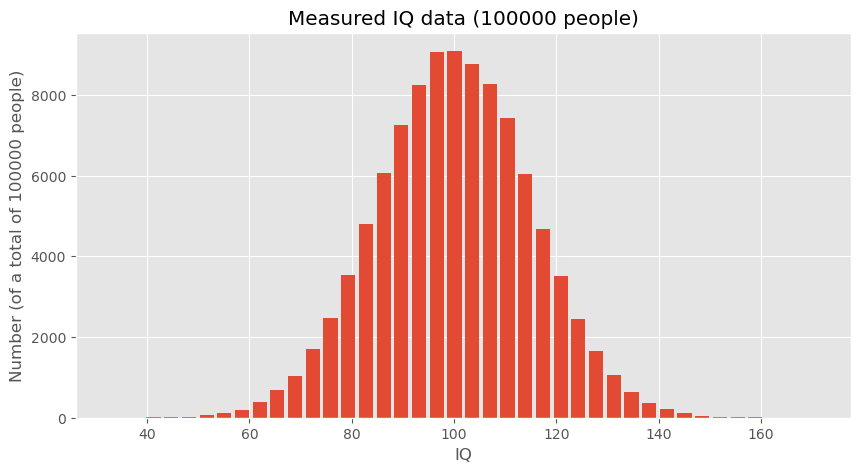

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(data_iq_large, 40, rwidth=0.8)
ax.set_title("IQs")
ax.set_xlabel("IQ")
ax.set_ylabel(f"Number (of a total of {len(data_iq_large)} people)")
ax.set_title(f"Measured IQ data ({len(data_iq_large)} people)")

#plt.savefig("example_statistics_iq_distribution.png", dpi=300)
plt.show()

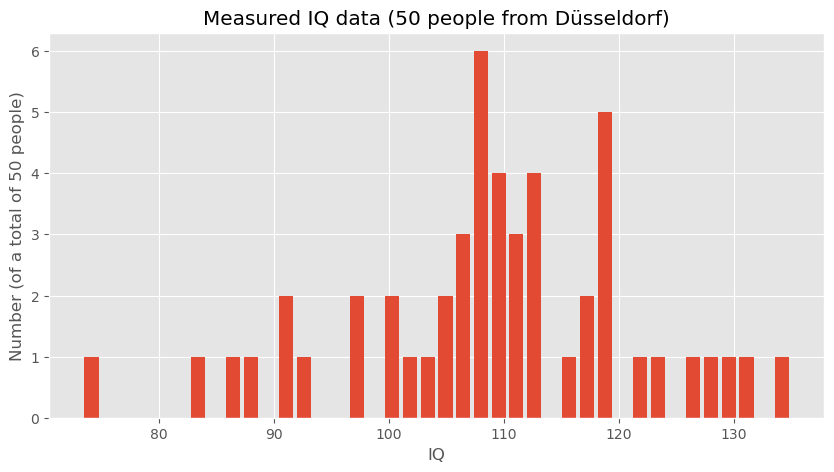

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(data_iq_duesseldorf, 40, rwidth=0.8)
ax.set_title("IQs")
ax.set_xlabel("IQ")
ax.set_ylabel(f"Number (of a total of {len(data_iq_duesseldorf)} people)")
ax.set_title(f"Measured IQ data ({len(data_iq_duesseldorf)} people from Düsseldorf)")

#plt.savefig("example_statistics_iq_distribution.png", dpi=300)
plt.show()

**Analyzing the Data**  
After visualizing, the next step is to analyze the statistical measures:

In [39]:
print(f"Mean IQ (large dataset): {np.mean(data_iq_large)}")
print(f"Mean IQ (Düsseldorf): {np.mean(data_iq_duesseldorf)}")

Mean IQ (large dataset): 99.9863762384032
Mean IQ (Düsseldorf): 108.9020908464346


These calculations provide the mean IQ for both datasets, which can then be compared to draw preliminary conclusions about the differences between the general population and the subgroup from Düsseldorf.

### Hypothesis Testing

To formally address whether the observed difference in mean IQs between the general population and the Düsseldorf subgroup is statistically significant, we can employ hypothesis testing. This means that we start from a question or hypothesis which in this case could be:

**People in Düsseldorf smarter than the overall average? (given the data shown above)**

The underlying question is if the difference in mean IQ that we just computed is a reliable indicator for making such a bold statement or whether such a difference could also just be a mere coincidence. What do you think?


### Student-t-test

One way to answer this question is to perform a statistical test such as a **t-test** to compare the means of the two distributions. We here assume that you have heard of the *student t-test*, if not, you will easily find plenty of introduction material elsewhere (e.g., [on Wikipedia](https://en.wikipedia.org/wiki/Student%27s_t-test)). The null hypothesis (H0) would state that there is no difference in IQ between the general population and those from Düsseldorf, whereas the alternative hypothesis (H1) would suggest that there is a significant difference.

By conducting this test, we can determine whether the observed difference in means is likely due to random variation or if it's statistically significant, thereby suggesting that individuals from Düsseldorf might indeed have a higher average IQ compared to the general population.

For our hypothesis testing, we'll use the two-sample t-test because we are comparing the means from two independent samples. This test will help us understand if the differences in the means are significant or just due to random chance.

Here is the Python code that implements the t-test using the SciPy library, which provides the `ttest_ind` function specifically for this purpose:

In [40]:
# Importing the necessary function from scipy.stats
from scipy.stats import ttest_ind

# Conducting the t-test between the large dataset and the Düsseldorf dataset
t_stat, p_value = ttest_ind(data_iq_large, data_iq_duesseldorf)

# Output the results of the t-test
print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

T-Statistic: -4.201608996012756
P-Value: 2.652539818908803e-05


#### Interpreting the T-Test Results

The output of this test gives us two key pieces of information:

- **T-Statistic**: This value indicates the relative difference between the means in terms of the combined standard deviation of the two samples.
- **P-Value**: This value is the probability of obtaining results that are a least as extreme as the result actually observed, under the assumption that the null hypothesis is indeed correct. The lower this number is, the less likely it becomes to obtain such a result *by chance*.

In this example, the **p-value is very small**, which means that the observed difference would be very unlikely if both samples really came from the same underlying distribution. Or, in other words, it is extremely unlikely to observe such a big IQ discrepency merely by chance.

An alternative approach would to run a quick simulation.

### A simulation-based alternative

The t-test is a standard statistical tool, but it is not the only way to think about this question. A more intuitive alternative is to ask:

> **How unusual would our observed difference in means be if the Düsseldorf group were just a random sample from the general population?**

This way of thinking leads naturally to a **simulation-based test**. Instead of relying on a specific formula, we repeatedly simulate what would happen if we randomly drew many groups of 50 people from the general population and compared their mean IQ to the overall mean.

If the difference we observed for Düsseldorf appears frequently in such random samples, then the result would not be very surprising. If it appears only very rarely, then the observed difference is unlikely to be due to random sampling alone.

### Simulating random samples

The following Python code defines a function that repeatedly draws random samples of the same size as the Düsseldorf group and computes the difference between the population mean and the sample mean.

In [41]:
def simulated_mean_difference(data, n_samples):
    """Difference between the full data mean and the mean of a random sample."""
    return data.mean() - np.random.choice(data, n_samples).mean()

# Run many simulation experiments
simulated_differences = [simulated_mean_difference(data_iq_large, 50) for _ in range(10000)]

### Visualizing the simulated differences

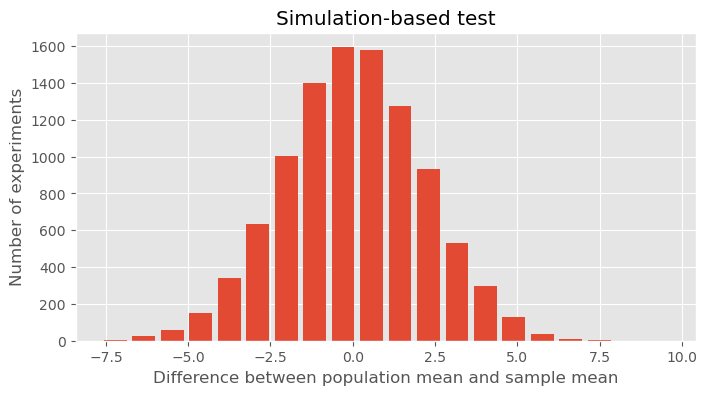

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(simulated_differences, 20, rwidth=0.8)
ax.set_title("Simulation-based test")
ax.set_xlabel("Difference between population mean and sample mean")
ax.set_ylabel("Number of experiments")
plt.show()

### Interpreting the result

The histogram shows the range of mean differences we would typically expect if we repeatedly drew random samples of 50 people from a population with mean IQ around 100.
In our toy example, the Düsseldorf sample had a mean IQ of about 109, so the observed difference from the large population mean was roughly 9 points. Looking at the histogram, we can ask:

> **Would such a large difference appear often just by random chance?**

Apparently not. In the simulation, differences of that size occur only very rarely. This suggests that the Düsseldorf sample is unlikely to be just an ordinary random sample from the same population distribution.

So the result supports the same general conclusion as the t-test: the observed difference is probably too large to be explained by random variation alone.

### A note of caution

Still, even this does **not** mean that we can confidently conclude that “people in Düsseldorf are more intelligent.” It only means that, under the assumptions of this toy example, the observed sample looks unusually high compared with what we would expect from random sampling.

As always in data science, statistical significance is not the same as a strong real-world conclusion. Study design, data quality, measurement, and interpretation still matter enormously.

## More on Basic Statistics for Data Science
In this chapter, we only covered a few of the absolute basics. There is a lot more to learn and discover when it comes to statistics in the context of data science. I have never met a data scientist who complained that he/she had spent too much time learning about statistics. In contrast, a complaint the other way around is fairly common. If you feel that your statistical skills are not fully up to speed, or if you would like to get a broader, deeper understanding I definitely recommend spending some time on this matter.

Here are a few (out of *many*) suitable textbooks on this matter:
- Peter Bruce and Andrew Bruce, "Practical Statistics for Data Scientists", 2017, {cite}`bruce_statistics_2017`
- Stanley Chan, "Introduction to Probability for Data Science", 2021, {cite}`chan2021probability`

Freely available online are the following books:
- "OpenIntro Statistics - Fourth Edition" by David Diez, Mine Cetinkaya-Rundel, Christopher D Barr, 2022, {cite}`diez_openintro_2022`, see [this link to the book](https://www.openintro.org/book/os/)
- "Introduction to Statistics and Data Analysis" by Christian Heumann and Michael Schomaker
Shalabh, {cite}`heumann_introduction_2022` [link to pdf](https://link.springer.com/content/pdf/10.1007/978-3-319-46162-5.pdf), this book contains code in R that can easily be converted to Python examples.
- "Statistical Methods for Data Analysis" by Luca Lista, {cite}`lista_statistical_2023` [link to pdf](https://link.springer.com/content/pdf/10.1007/978-3-031-19934-9.pdf)
- David Lane, "Introduction to Statistics", {cite}`lane_statistics_2003`, https://open.umn.edu/opentextbooks/textbooks/459